# DATA 230 Group Project — Data Cleaning and Processing
**US Accidents (2016–2023), full file: 7,728,394 rows × 46 columns** · Section owner: Saida Mahmood

Runs **locally** on your computer with the CSV you already downloaded. The notebook is self-contained: Step 2 writes the cleaning code next to the CSV, so nothing else needs to be copied.

### How to run
1. Check the path in Step 1 points to your `US_Accidents_March23.csv`.
2. **Kernel → Restart & Run All** (Jupyter) or **Restart → Run All** (VS Code).
3. Wait for **"All checks passed."** at the end. Results are saved in the same folder as the CSV: `data/clean/`, `figures/`, `src/`.

One-time setup in Terminal: `pip install pandas numpy matplotlib pyarrow jupyter`

| Output | Used by |
|---|---|
| `data/clean/us_accidents_clean/` — cleaned, de-duplicated, **not imputed**, with quality flags and `Split` / `Split_Time` columns (folder of parquet parts) | everyone |
| `data/clean/imputation_stats.csv` — weather medians fitted on **training rows only** | ML direction |
| `data/clean/data_dictionary.csv`, `report_numbers.csv`, `invalid_values_log.csv`, `cleaning_log.json` | report and presentation |
| `figures/cleaning_fig1 … fig10.png` (500 dpi) + `figures/figure_captions.md` | report and presentation |

In [1]:
# ---- Print run time and memory after every cell (no installation needed) ----
import time as _time
try:
    _ip = get_ipython()
except NameError:
    _ip = None
if _ip is not None and not getattr(_ip, "_cell_timer_on", False):
    try:
        import psutil as _psutil
    except ImportError:
        _psutil = None

    def _start_timer(*args):
        _ip.user_ns["_cell_start"] = _time.perf_counter()

    def _stop_timer(*args):
        start = _ip.user_ns.pop("_cell_start", None)
        if start is None:
            return
        secs = _time.perf_counter() - start
        mem = f" | memory in use: {_psutil.Process().memory_info().rss / 1e9:.1f} GB" if _psutil else ""
        print(f"⏱ cell run time: {int(secs // 60)} min {secs % 60:.1f} s{mem}")

    _ip.events.register("pre_run_cell", _start_timer)
    _ip.events.register("post_run_cell", _stop_timer)
    _ip._cell_timer_on = True
    print("Cell timer on: every cell now prints its run time and memory use.")
# -----------------------------------------------------------------------------

# ===== Step 1: where your CSV is - edit this one line if you move the file =====
CSV_PATH = "/Users/saidamahmood/Desktop/Local/US_Accidents_March23.csv"
# ================================================================================
import os, shutil, sys
from pathlib import Path

CSV_PATH = Path(CSV_PATH).expanduser()
assert CSV_PATH.exists(), f"CSV not found: {CSV_PATH}  - check the folder and file name."
WORK_DIR = CSV_PATH.parent
os.chdir(WORK_DIR)                    # outputs are written next to the CSV
sys.path.insert(0, str(WORK_DIR))     # the cleaning module is written here in Step 2
print(f"CSV found ({CSV_PATH.stat().st_size / 1e9:.2f} GB). Outputs go to {WORK_DIR}")

Cell timer on: every cell now prints its run time and memory use.
CSV found (3.06 GB). Outputs go to /Users/saidamahmood/Desktop/Local


## Step 2: write the cleaning module
The next cell saves all cleaning functions as `us_accidents_cleaning.py` in the CSV's folder (`%%writefile`), so `import us_accidents_cleaning` always works. A copy also goes to `src/` for the team and GitHub.

In [2]:
%%writefile us_accidents_cleaning.py
"""
us_accidents_cleaning.py
DATA 230 group project (US Accidents 2016-2023) - Data Cleaning and Processing
Owner: Saida Mahmood

One module, three passes over the 3 GB CSV, one shared output:

    Pass 1  audit_raw()            raw-file audit + exact-duplicate screen (chunked)
    Pass 2  clean_to_parts()       row-level cleaning, written as parquet parts (chunked)
    Pass 3  finalize()             near-duplicate screen, leakage-safe split,
                                   train-only imputation statistics, final parquet

The rest of the team only needs:
    df    = load_clean("data/clean/us_accidents_clean.parquet")
    stats = load_imputation_stats("data/clean/imputation_stats.csv")
    X, y  = build_model_frame(df[df.Split == "train"], stats)

Every threshold below is a named constant so the decision table can cite it.
"""
from __future__ import annotations

import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar

# --------------------------------------------------------------------------------------
# Constants
# --------------------------------------------------------------------------------------
PIPELINE_VERSION = "3.2"   # saved in checkpoints; a change forces a fresh run
TARGET = "Severity"
TARGET_LEVELS = [1, 2, 3, 4]
TS_FORMAT = "%Y-%m-%d %H:%M:%S"
CHUNKSIZE = 250_000   # rows per block: every value is read as text, so smaller blocks keep peak memory low

# Coverage of the March-2023 release. Rows outside it are invalid records.
VALID_START = pd.Timestamp("2016-01-01")
VALID_END = pd.Timestamp("2023-04-01")

# Contiguous-US bounding box (the file has no AK/HI rows). Tighter than the
# plain world bounds (+-90 / +-180), so a swapped sign or a
# lat/lng swap is caught instead of passing as "valid".
US_BOUNDS = {"Start_Lat": (24.0, 50.0), "Start_Lng": (-125.0, -66.0),
             "End_Lat": (24.0, 50.0), "End_Lng": (-125.0, -66.0)}

# Two tiers of invalid readings, both -> NaN + *_was_invalid flag (the row is always kept):
#   "definition"   - violates the definition of the quantity (negative amounts, pressure <= 0,
#                    humidity outside 0-100 %, below absolute zero): impossible.
#   "plausibility" - inside the definition but beyond documented US records (limits below):
#                    implausible, most likely a sensor or unit error.
# These are domain limits, NOT statistical outliers (see OUTLIER POLICY below).
# Limits sit just beyond documented US records, so the rule reads "beyond anything ever
# observed" rather than "looks too high". Values are masked, never the row, and every masked
# value is written to invalid_values_log.csv (ID, column, original value) so a
# definition-only view (mask only physically impossible values) can be restored exactly.
VALID_RANGES = {
    "Temperature(F)": (-70, 134),   # contiguous-US records: -70 F (MT 1954), 134 F (Death Valley 1913)
    "Humidity(%)": (1, 100),        # 0 % relative humidity does not occur in air (none found)
    "Pressure(in)": (15, 35),       # 0 inHg is a vacuum; highest US stations ~19-20 inHg
    "Visibility(mi)": (0, 100),
    "Wind_Speed(mph)": (0, 150),    # above the strongest hurricane winds measured at stations
    "Precipitation(in)": (0, 12),   # US short-duration rainfall record ~12 in in < 1 h
}
WEATHER_NUMERIC = list(VALID_RANGES)
WIND_CHILL_RANGE = (-110, 134)
DEFINITION_LIMITS = {          # (lowest valid, highest valid, strictly-greater-than-lowest?)
    "Temperature(F)": (-459.67, None, False), "Humidity(%)": (0, 100, False),
    "Pressure(in)": (0, None, True), "Visibility(mi)": (0, None, False),
    "Wind_Speed(mph)": (0, None, False), "Precipitation(in)": (0, None, False),
    "Wind_Chill(F)": (-459.67, None, False),
}


def definition_invalid(col: str, v: pd.Series) -> pd.Series:
    if col not in DEFINITION_LIMITS:
        return pd.Series(False, index=v.index)
    lo, hi, strict = DEFINITION_LIMITS[col]
    bad = (v <= lo) if strict else (v < lo)
    if hi is not None:
        bad |= v > hi
    return bad.fillna(False)      # wind chill is kept for EDA only; also must not exceed temperature

DURATION_MAX_PLAUSIBLE_MIN = 365 * 24 * 60  # > 1 year: implausible End_Time -> Duration NaN + flag
COVERAGE_START = pd.Timestamp("2016-02-01")  # documented start; earlier rows are kept but counted
NEAR_DUP_WINDOW_MIN = 10                     # same ~110 m cell, starts <= 10 min apart -> same event group
WEATHER_FEED_CHANGE = pd.Timestamp("2019-04-01")  # weather vocabulary + missingness break (see audit / Figure C5)
WEATHER_STALE_MIN = 60                      # |weather obs - accident start| > 60 min

BOOLEAN_COLUMNS = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway",
    "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal", "Turning_Loop",
]
POI_FLAGS = [c for c in BOOLEAN_COLUMNS if c != "Turning_Loop"]

WIND_DIRECTION_MAP = {
    "CALM": "CALM", "VARIABLE": "VAR", "VAR": "VAR",
    "N": "N", "NORTH": "N", "NNE": "NNE", "NE": "NE", "NORTHEAST": "NE", "ENE": "ENE",
    "E": "E", "EAST": "E", "ESE": "ESE", "SE": "SE", "SOUTHEAST": "SE", "SSE": "SSE",
    "S": "S", "SOUTH": "S", "SSW": "SSW", "SW": "SW", "SOUTHWEST": "SW", "WSW": "WSW",
    "W": "W", "WEST": "W", "WNW": "WNW", "NW": "NW", "NORTHWEST": "NW", "NNW": "NNW",
}

# Labels that replace each other in April 2019 (synchronised switch in every provider).
WEATHER_LABEL_HARMONIZE = {"Clear": "Fair", "Overcast": "Cloudy", "Thunderstorm": "T-Storm"}

# Text that means "no value" (exact match after trim + lower case).
PLACEHOLDER_TOKENS = {"", "na", "n/a", "nan", "null", "none", "unknown", "?", "-", "--", "---",
                      "missing", "not available", "undefined"}

# Free text that is (almost) unique per row: scanning it value by value is the slowest part of
# the audit. Its placeholders are still counted (and converted) during cleaning.
AUDIT_TEXT_SKIP = {"ID", "Description"}

# Raw column groups used to normalise a row before the duplicate hash.
RAW_NUMERIC = ["Severity", "Start_Lat", "Start_Lng", "End_Lat", "End_Lng", "Distance(mi)",
               "Temperature(F)", "Wind_Chill(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)",
               "Wind_Speed(mph)", "Precipitation(in)"]
RAW_TIMES = ["Start_Time", "End_Time", "Weather_Timestamp"]

# Inspection thresholds for "repeated extreme value" (sentinel) screening. Not cleaning rules.
EXTREME_INSPECT = {"Temperature(F)": (-40, 120), "Humidity(%)": (0.5, 100.5), "Pressure(in)": (20, 32),
                   "Visibility(mi)": (-1, 50), "Wind_Speed(mph)": (-1, 60), "Precipitation(in)": (-1, 2)}

# First matching pattern wins ("Thunderstorms and Rain" -> Thunderstorm).
WEATHER_GROUPS = [
    ("Precipitation (type unknown)", r"n/a precipitation"),
    ("Thunderstorm", r"thunder|t-storm|tstorm"),
    ("Severe wind", r"tornado|funnel|squall"),
    ("Snow/Ice", r"snow|sleet|ice|wintry|freezing|hail"),
    ("Rain", r"rain|drizzle|shower"),
    ("Fog/Low visibility", r"fog|mist|haze|smoke|dust|sand|ash"),
    ("Cloudy", r"cloud|overcast"),
    ("Clear/Fair", r"fair|clear"),
]

# Road type from the street name (heuristic, first match wins).
ROAD_TYPE_RULES = [
    ("Interstate", r"\bI-\s?\d+|\bI\s\d+\b|\bINTERSTATE\b"),
    ("Freeway/Expressway", r"\b(?:FWY|FREEWAY|EXPY|EXPWY|EXPRESSWAY|TPKE|TURNPIKE|TOLLWAY|"
                           r"BELTWAY|THRUWAY|PKWY|PARKWAY)\b"),
    ("US/State highway", r"\bUS-?\s?\d+|\bUS HIGHWAY\b|\bSTATE (?:ROUTE|HIGHWAY|HWY|RD|ROAD)\b|"
                         r"\bSR-?\s?\d+|\b[A-Z]{2}-\d+\b|\bHWY\b|\bHIGHWAY\b|\bROUTE\b|\bRTE\b"),
]

# Lookup "join": US Census Bureau regions.
CENSUS_REGION = {
    **{s: "Northeast" for s in ["CT", "ME", "MA", "NH", "RI", "VT", "NJ", "NY", "PA"]},
    **{s: "Midwest" for s in ["IL", "IN", "MI", "OH", "WI", "IA", "KS", "MN", "MO", "NE", "ND", "SD"]},
    **{s: "South" for s in ["DE", "DC", "FL", "GA", "MD", "NC", "SC", "VA", "WV", "AL", "KY", "MS",
                            "TN", "AR", "LA", "OK", "TX"]},
    **{s: "West" for s in ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY", "AK", "CA", "HI", "OR", "WA"]},
}

# Raw columns removed from the shared dataset. Only constants: every other raw column stays in
# the shared file (cleaned) so EDA and the dashboard can still use it. What the MODEL may use is
# decided by COLUMN_ROLES / build_model_frame(), not by deleting columns here.
DROPPED_COLUMNS = {
    "Country": "constant (US)",
    "Turning_Loop": "constant (False)",
}
# Heavy free-text columns skipped by load_clean() unless asked for (memory).
HEAVY_COLUMNS = ["Description", "Street"]

# Role of every column in the shared dataset. build_model_frame() reads this.
COLUMN_ROLES = {
    "ID": "identifier",
    "Severity": "target",
    # Known at accident onset -> eligible model features
    "Start_Lat": "feature", "Start_Lng": "feature", "State": "feature", "Region": "feature",
    "Timezone": "feature", "Road_Type": "feature",
    **{c: "feature" for c in WEATHER_NUMERIC},
    "Wind_Direction": "feature", "Weather_Group": "feature", "Weather_Windy": "feature",
    "Weather_All_Missing": "quality_flag",   # encodes the collection period, like *_was_missing
    **{c: "feature" for c in POI_FLAGS},
    "Sunrise_Sunset": "feature",
    "Start_DayOfWeek": "feature", "Start_Hour": "feature",
    "Is_Weekend": "feature", "Is_Holiday": "feature", "Is_Rush_Hour": "feature",
    # Describe HOW the label was produced, not the road. Team decision needed.
    "Source": "label_process", "Start_Year": "label_process", "Start_Month": "label_process",
    "Weather_Period": "label_process",
    # Known only after the accident -> never a feature (EDA / dashboard only)
    "End_Time": "leakage_post_event", "Duration_min": "leakage_post_event",
    "Distance(mi)": "leakage_post_event", "End_Lat": "leakage_post_event",
    "End_Lng": "leakage_post_event", "Description": "leakage_post_event",
    # Useful for EDA / dashboard, too granular to model directly
    "Start_Time": "eda_only", "City": "eda_only", "County": "eda_only", "Zip5": "eda_only",
    "Weather_Condition": "eda_only", "Street": "eda_only", "Zipcode": "eda_only",
    "Airport_Code": "eda_only", "Weather_Timestamp": "eda_only", "Wind_Chill(F)": "eda_only",
    "Civil_Twilight": "eda_only", "Nautical_Twilight": "eda_only",
    "Astronomical_Twilight": "eda_only",
    # Data-quality bookkeeping
    **{f"{c}_was_invalid": "quality_flag" for c in WEATHER_NUMERIC},
    "Duration_invalid": "quality_flag", "Weather_Lag_min": "quality_flag",
    "Weather_Stale": "quality_flag", "Dup_Group_Size": "quality_flag",
    "Dup_Source_Count": "quality_flag", "Dup_Severity_Conflict": "quality_flag",
    "Same_Event_Repeat": "quality_flag", "Before_Coverage": "quality_flag",
    "Wind_Chill(F)_was_invalid": "quality_flag", "Sunrise_Sunset_filled": "quality_flag",
    "Timezone_was_filled": "quality_flag",
    "Split_Time": "split",
    "Event_Key": "quality_flag", "Split": "split",
}

CATEGORICAL_COLUMNS = [
    "Airport_Code", "Zipcode", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight",
    "Weather_Period", "Source", "State", "Region", "Timezone", "City", "County", "Zip5", "Road_Type",
    "Wind_Direction", "Weather_Condition", "Weather_Group", "Sunrise_Sunset",
]
FLOAT_COLUMNS = ["Start_Lat", "Start_Lng", "End_Lat", "End_Lng", "Wind_Chill(F)", "Distance(mi)", *WEATHER_NUMERIC,
                 "Duration_min", "Weather_Lag_min"]
INT8_COLUMNS = [*POI_FLAGS, *[f"{c}_was_invalid" for c in WEATHER_NUMERIC], "Weather_Windy",
                "Weather_All_Missing", "Weather_Stale", "Duration_invalid", "Is_Weekend",
                "Is_Holiday", "Is_Rush_Hour", "Before_Coverage", "Wind_Chill(F)_was_invalid",
                "Sunrise_Sunset_filled", "Timezone_was_filled", "Start_Month", "Start_DayOfWeek", "Start_Hour"]
FINAL_COLUMN_ORDER = [
    "ID", "Source", "Severity", "Start_Time", "End_Time", "Duration_min", "Duration_invalid",
    "Start_Year", "Start_Month", "Start_DayOfWeek", "Start_Hour", "Is_Weekend", "Is_Holiday",
    "Is_Rush_Hour", "Before_Coverage", "Weather_Period",
    "Start_Lat", "Start_Lng", "End_Lat", "End_Lng", "Distance(mi)", "Description",
    "Street", "Road_Type", "State", "Region", "County", "City", "Zipcode", "Zip5", "Timezone",
    "Timezone_was_filled",
    "Airport_Code", "Weather_Timestamp", "Weather_Lag_min", "Weather_Stale",
    *WEATHER_NUMERIC, *[f"{c}_was_invalid" for c in WEATHER_NUMERIC],
    "Wind_Chill(F)", "Wind_Chill(F)_was_invalid",
    "Wind_Direction", "Weather_Condition", "Weather_Group", "Weather_Windy",
    "Weather_All_Missing", *POI_FLAGS, "Sunrise_Sunset", "Sunrise_Sunset_filled",
    "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight",
]
PASS3_COLUMNS = ["Event_Key", "Same_Event_Repeat", "Dup_Group_Size", "Dup_Source_Count",
                 "Dup_Severity_Conflict", "Split", "Split_Time"]

# --------------------------------------------------------------------------------------
# Small helpers
# --------------------------------------------------------------------------------------
def parse_timestamp(series: pd.Series) -> pd.Series:
    """Up to three text formats coexist ('...05:46:00', '...05:46:00.000000000', ...).
    Format inference silently turns some of them into NaT, so the first 19 characters are
    parsed with an explicit format; anything that still fails gets a strict ISO-8601 retry
    (e.g. a 'T' separator) instead of being dropped silently."""
    text = series.astype("string").str.strip()
    out = pd.to_datetime(text.str.slice(0, 19), format=TS_FORMAT, errors="coerce")
    retry = out.isna() & text.notna()
    if retry.any():
        out[retry] = pd.to_datetime(text[retry], format="ISO8601", errors="coerce")
    return out


def solar_elevation(lat, lng, utc):
    """Approximate solar elevation (degrees) - NOAA general solar position equations.
    lat/lng in degrees (lng negative = west), utc a tz-naive UTC datetime Series."""
    doy = utc.dt.dayofyear.to_numpy("float64")
    hours = (utc.dt.hour + utc.dt.minute / 60 + utc.dt.second / 3600).to_numpy("float64")
    g = 2 * np.pi / 365 * (doy - 1 + (hours - 12) / 24)
    eqtime = 229.18 * (0.000075 + 0.001868 * np.cos(g) - 0.032077 * np.sin(g)
                       - 0.014615 * np.cos(2 * g) - 0.040849 * np.sin(2 * g))
    decl = (0.006918 - 0.399912 * np.cos(g) + 0.070257 * np.sin(g) - 0.006758 * np.cos(2 * g)
            + 0.000907 * np.sin(2 * g) - 0.002697 * np.cos(3 * g) + 0.00148 * np.sin(3 * g))
    tst = hours * 60 + eqtime + 4 * np.asarray(lng, "float64")
    ha = np.radians(tst / 4 - 180)
    phi = np.radians(np.asarray(lat, "float64"))
    cos_zen = np.sin(phi) * np.sin(decl) + np.cos(phi) * np.cos(decl) * np.cos(ha)
    return 90 - np.degrees(np.arccos(np.clip(cos_zen, -1, 1)))


STANDARD_UTC_OFFSET_H = {"US/Eastern": -5, "US/Central": -6, "US/Mountain": -7, "US/Pacific": -8}
NO_DST_STATES = {"AZ"}   # Arizona stays on standard time (the dataset has no HI/AK rows)


def _dst_window(year: int):
    """US daylight saving time (rules since 2007): 2nd Sunday of March 02:00 to
    1st Sunday of November 02:00, local clock time."""
    mar = pd.Timestamp(year=year, month=3, day=1)
    start = mar + pd.Timedelta(days=(6 - mar.dayofweek) % 7 + 7, hours=2)
    nov = pd.Timestamp(year=year, month=11, day=1)
    end = nov + pd.Timedelta(days=(6 - nov.dayofweek) % 7, hours=2)
    return start, end


DST_WINDOWS = {y: _dst_window(y) for y in range(2015, 2025)}


def local_to_utc(local_time: pd.Series, timezone: pd.Series, state: pd.Series) -> pd.Series:
    """Convert the dataset's local clock times to UTC with fixed US rules, so no time-zone
    database (tzdata/pytz) is needed. Unknown time zones give NaT."""
    std = timezone.astype("string").map(STANDARD_UTC_OFFSET_H).astype("float64")
    year = local_time.dt.year
    start = year.map({y: w[0] for y, w in DST_WINDOWS.items()})
    end = year.map({y: w[1] for y, w in DST_WINDOWS.items()})
    in_dst = (local_time >= pd.to_datetime(start)) & (local_time < pd.to_datetime(end))
    in_dst &= ~state.astype("string").isin(NO_DST_STATES).fillna(False)
    offset_h = std + in_dst.astype("float64")
    return local_time - pd.to_timedelta(offset_h, unit="h")


def day_or_night(local_time, timezone, lat, lng, state) -> pd.Series:
    """'Day'/'Night' from the sun's position (sunrise/sunset at -0.833 degrees), using the
    accident's local clock time, its Timezone and State. NA where any input is missing."""
    result = pd.Series(pd.NA, index=local_time.index, dtype="string")
    utc = local_to_utc(local_time, timezone, state)
    ok = utc.notna() & lat.notna() & lng.notna()
    if ok.any():
        elev = solar_elevation(lat[ok], lng[ok], utc[ok])
        result[ok] = np.where(elev < -0.833, "Night", "Day")
    return result


_PLACEHOLDER_MAX_LEN = max(len(t) for t in PLACEHOLDER_TOKENS)


def _is_placeholder(text: pd.Series) -> pd.Series:
    """True where the (already trimmed) text is a placeholder token. Only short strings can
    be tokens, so long values such as descriptions are skipped instead of lower-cased."""
    result = pd.Series(False, index=text.index)
    short = (text.str.len() <= _PLACEHOLDER_MAX_LEN).fillna(False).astype(bool)
    if short.any():
        result[short] = text[short].str.lower().isin(PLACEHOLDER_TOKENS).to_numpy()
    return result


def by_unique(func):
    """Decorator: run a text function on the DISTINCT values only, then map the results back
    to every row. Identical output; a 500,000-row block of a flag column has 2 distinct values,
    so the work drops from 500,000 string operations to 2."""
    def wrapper(series: pd.Series, *args, **kwargs) -> pd.Series:
        codes, uniques = pd.factorize(series.astype("string"), use_na_sentinel=True)
        if len(uniques) > 0.5 * len(series):           # mostly unique (e.g. Description)
            return func(series, *args, **kwargs)
        done = func(pd.Series(uniques, dtype="string"), *args, **kwargs)
        values = done.to_numpy(dtype=object, na_value=pd.NA)
        out = np.empty(len(codes), dtype=object)
        out[codes >= 0] = values[codes[codes >= 0]]
        out[codes < 0] = func(pd.Series([pd.NA], dtype="string"), *args, **kwargs).iloc[0]
        return pd.Series(out, index=series.index, dtype=done.dtype)
    wrapper.__name__, wrapper.__doc__ = func.__name__, func.__doc__
    return wrapper


@by_unique
def clean_text(series: pd.Series, case: str | None = None) -> pd.Series:
    out = series.astype("string")
    # Fast path: only values with a tab/newline/non-breaking space or a double space need the
    # (slow) regex replacement; everything else only needs strip(). Same result, much faster.
    messy = out.str.contains(r"\s\s|[^\S ]", regex=True).fillna(False).astype(bool)
    if messy.any():
        out[messy] = out[messy].str.replace(r"\s+", " ", regex=True)
    out = out.str.strip()
    out = out.mask(_is_placeholder(out))
    if case == "upper":
        return out.str.upper()
    if case == "title":
        return out.str.title()
    return out


@by_unique
def normalize_wind_direction(series: pd.Series) -> pd.Series:
    upper = clean_text(series, "upper")
    return upper.map(WIND_DIRECTION_MAP).fillna(upper).astype("string")


@by_unique
def group_weather(series: pd.Series) -> pd.Series:
    lowered = series.astype("string").str.lower()
    group = pd.Series(pd.NA, index=series.index, dtype="string")
    for name, pattern in WEATHER_GROUPS:
        hit = lowered.str.contains(pattern, regex=True).fillna(False).astype(bool) & group.isna()
        group[hit] = name
    group[lowered.notna() & group.isna()] = "Other"
    return group


@by_unique
def classify_road(street: pd.Series) -> pd.Series:
    upper = clean_text(street, "upper")
    road = pd.Series(pd.NA, index=street.index, dtype="string")
    for name, pattern in ROAD_TYPE_RULES:
        hit = upper.str.contains(pattern, regex=True).fillna(False).astype(bool) & road.isna()
        road[hit] = name
    road[upper.notna() & road.isna()] = "Local road"
    return road.fillna("Unknown")


@by_unique
def zip5(series: pd.Series) -> pd.Series:
    return series.astype("string").str.extract(r"^\s*(\d{5})", expand=False).astype("string")


def us_holidays() -> set:
    cal = USFederalHolidayCalendar()
    return set(cal.holidays(start="2015-12-01", end="2023-12-31").date)


HOLIDAYS = us_holidays()


def row_hash_without_id(raw: pd.DataFrame) -> np.ndarray:
    """Raw-text hash of every column except ID (the naive definition, reported for comparison)."""
    return pd.util.hash_pandas_object(raw.drop(columns=["ID"], errors="ignore"),
                                      index=False).to_numpy(dtype="uint64")


def normalized_row_hash(raw: pd.DataFrame) -> np.ndarray:
    """Hash of the row's MEANING, not its text: timestamps cut to 19 characters (the same
    instant is stored with and without '.000000000'), numbers parsed to float64 ('10' ==
    '10.0'), text whitespace-trimmed (incl. non-breaking spaces). ID excluded."""
    out = raw.drop(columns=["ID"], errors="ignore").copy()
    for col in out.columns:
        if col in RAW_TIMES:
            out[col] = out[col].str.slice(0, 19)
        elif col in RAW_NUMERIC:
            out[col] = pd.to_numeric(out[col], errors="coerce").astype("float64")
        else:
            out[col] = _squeeze_spaces(out[col])
    return pd.util.hash_pandas_object(out, index=False).to_numpy(dtype="uint64")


@by_unique
def _squeeze_spaces(series: pd.Series) -> pd.Series:
    """Whitespace runs -> one space, then trim (used only for the duplicate fingerprint)."""
    return series.astype("string").str.replace(r"\s+", " ", regex=True).str.strip()


def read_raw_chunks(path, chunksize=CHUNKSIZE):
    """Every column as text. Type conversion is then explicit (and counted)."""
    # Only empty fields become NaN. pandas' default would silently turn text such as "NA",
    # "None" or "null" into NaN before the audit could count it as a placeholder.
    return pd.read_csv(path, chunksize=chunksize, dtype=str, keep_default_na=False, na_values=[""])


def load_raw(path, require_arrow=True) -> pd.DataFrame:
    """Read the WHOLE CSV into memory once (all 7.7 M rows, every column as text).

    Text is stored as Arrow strings (pandas 'string[pyarrow]'), which keeps the file at
    roughly 3-4 GB in memory. Without pyarrow, pandas would store 355 million Python string
    objects (well over 20 GB), so this raises instead of freezing the computer.
    Same reading rule as chunk mode: only empty fields become missing."""
    try:
        import pyarrow  # noqa: F401
        dtype = "string[pyarrow]"
    except ImportError:
        if require_arrow:
            raise RuntimeError("Whole-file mode needs pyarrow (pip install pyarrow). "
                               "Without it, use chunk mode: READ_WHOLE_FILE = False.")
        dtype = str
    return pd.read_csv(path, dtype=dtype, keep_default_na=False, na_values=[""])


def iter_source(source, chunksize=CHUNKSIZE):
    """Yield row blocks from either a CSV path (read block by block) or a DataFrame already
    in memory (sliced, without copying the file again). Both give identical results."""
    if isinstance(source, pd.DataFrame):
        step = chunksize or len(source)
        for start in range(0, len(source), step):
            yield source.iloc[start:start + step]
    elif chunksize is None:
        yield read_raw_chunks(source, None)          # whole file as one block
    else:
        yield from read_raw_chunks(source, chunksize)


def _add(total, part):
    return part if total is None else total.add(part, fill_value=0)


# --------------------------------------------------------------------------------------
# Pass 1 - raw audit and exact-duplicate screen
# --------------------------------------------------------------------------------------
def _dup_summary(parts):
    h = np.sort(np.concatenate(parts))
    repeated = h[1:][h[1:] == h[:-1]]
    return int(len(repeated)), np.unique(repeated)


def audit_raw(path, chunksize=CHUNKSIZE) -> dict:
    """`path` may be the CSV path (chunk mode) or the DataFrame from load_raw() (whole-file mode)."""
    t0 = time.perf_counter()
    rows, columns = 0, None
    missing = None
    severity = None
    invalid = {f"{c} outside {lo}..{hi}": 0 for c, (lo, hi) in VALID_RANGES.items()}
    invalid.update({f"{c} outside US box": 0 for c in US_BOUNDS})
    invalid.update({"Severity not in 1-4": 0, "Distance(mi) negative": 0})
    time_checks = {"Start_Time unparsed": 0, "Start_Time outside 2016-01..2023-03": 0,
                   "Start_Time before documented Feb 2016": 0, "End_Time before Start_Time": 0,
                   "End_Time equal to Start_Time": 0, "Duration > 1 day": 0, "Duration > 365 days": 0,
                   "Weather_Timestamp > 1 h from start": 0, "Weather_Timestamp > 6 h from start": 0}
    fractional = {c: 0 for c in RAW_TIMES}
    placeholders = {}
    whitespace = {}
    label_counts = {"Wind_Direction": None, "Weather_Condition": None, "City": None, "County": None}
    zip_formats = None
    state_tz = None
    county_tz = None
    labels = {"Sunrise_Sunset": set(), "Source": set(), "Timezone": set(), "Country": set(),
              "Turning_Loop": set()}
    cardinality = {c: set() for c in ["State", "Street", "Zipcode", "Airport_Code"]}
    raw_parts, norm_parts, id_parts = [], [], []
    num_min, num_max = {}, {}
    extremes = []

    for block, raw in enumerate(iter_source(path, chunksize), start=1):
        rows += len(raw)
        print(f"  audit: block {block} ({rows:,} rows read, {time.perf_counter() - t0:.0f} s)", flush=True)
        gc.collect()
        if columns is None:
            columns = list(raw.columns)
        missing = _add(missing, raw.isna().sum())
        raw_parts.append(row_hash_without_id(raw))
        norm_parts.append(normalized_row_hash(raw))
        id_parts.append(pd.util.hash_pandas_object(raw["ID"], index=False).to_numpy("uint64"))

        nums = {c: pd.to_numeric(raw[c], errors="coerce") for c in RAW_NUMERIC}   # parse each number column once
        sev = nums[TARGET]
        severity = _add(severity, sev.value_counts(dropna=False))
        invalid["Severity not in 1-4"] += int((~sev.isin(TARGET_LEVELS)).sum())

        # Timestamps
        for col in RAW_TIMES:
            fractional[col] += int((raw[col].str.len() > 19).sum())
        start, end = parse_timestamp(raw["Start_Time"]), parse_timestamp(raw["End_Time"])
        wts = parse_timestamp(raw["Weather_Timestamp"])
        dur = end - start
        gap = (wts - start).abs()
        time_checks["Start_Time unparsed"] += int((start.isna() & raw["Start_Time"].notna()).sum())
        time_checks["Start_Time outside 2016-01..2023-03"] += int(
            (start.notna() & ((start < VALID_START) | (start >= VALID_END))).sum())
        time_checks["Start_Time before documented Feb 2016"] += int((start < COVERAGE_START).sum())
        time_checks["End_Time before Start_Time"] += int((dur < pd.Timedelta(0)).sum())
        time_checks["End_Time equal to Start_Time"] += int((dur == pd.Timedelta(0)).sum())
        time_checks["Duration > 1 day"] += int((dur > pd.Timedelta(days=1)).sum())
        time_checks["Duration > 365 days"] += int((dur > pd.Timedelta(days=365)).sum())
        time_checks["Weather_Timestamp > 1 h from start"] += int((gap > pd.Timedelta(hours=1)).sum())
        time_checks["Weather_Timestamp > 6 h from start"] += int((gap > pd.Timedelta(hours=6)).sum())

        # Numbers
        for col, (lo, hi) in VALID_RANGES.items():
            v = nums[col]
            invalid[f"{col} outside {lo}..{hi}"] += int(((v < lo) | (v > hi)).sum())
        for col, (lo, hi) in US_BOUNDS.items():
            v = nums[col]
            invalid[f"{col} outside US box"] += int(((v < lo) | (v > hi)).sum())
        dist = nums["Distance(mi)"]
        invalid["Distance(mi) negative"] += int((dist < 0).sum())
        for col in ["Start_Lat", "Start_Lng", "Distance(mi)", *WEATHER_NUMERIC, "Wind_Chill(F)"]:
            v = nums[col]
            num_min[col] = float(np.nanmin([num_min.get(col, np.inf), v.min()]))
            num_max[col] = float(np.nanmax([num_max.get(col, -np.inf), v.max()]))
        for col, (lo, hi) in EXTREME_INSPECT.items():
            v = nums[col]
            m = (v < lo) | (v > hi)
            if m.any():
                extremes.append(pd.DataFrame({"column": col, "value": v[m].to_numpy(),
                                              "station": raw.loc[m, "Airport_Code"].fillna("NA").to_numpy()}))

        # Text quality
        for col in raw.columns:
            if col in RAW_NUMERIC or col in RAW_TIMES or col in AUDIT_TEXT_SKIP:
                continue
            vc = raw[col].value_counts()                 # distinct values with their counts
            values = pd.Series(vc.index.astype(str), dtype="string")
            stripped = values.str.strip()
            whitespace[col] = whitespace.get(col, 0) + int(vc.to_numpy()[(values != stripped).to_numpy()].sum())
            ph = _is_placeholder(stripped).to_numpy()
            for val, n in zip(values[ph], vc.to_numpy()[ph]):
                placeholders[(col, val)] = placeholders.get((col, val), 0) + int(n)
        for col in label_counts:
            label_counts[col] = _add(label_counts[col], raw[col].value_counts())
        zip_formats = _add(zip_formats, raw["Zipcode"].str.replace(r"\d", "9", regex=True).value_counts())
        state_tz = _add(state_tz, pd.crosstab(raw["State"], raw["Timezone"]))
        county_key = clean_text(raw["State"], "upper").fillna("") + "|" + clean_text(raw["County"], "upper").fillna("")
        county_tz = _add(county_tz, pd.crosstab(county_key, clean_text(raw["Timezone"])))
        for col, s in labels.items():
            s.update(raw[col].dropna().unique().tolist())
        for col, s in cardinality.items():
            s.update(raw[col].dropna().unique().tolist())

    n_raw_dup, _ = _dup_summary(raw_parts)
    n_norm_dup, dup_hashes = _dup_summary(norm_parts)
    ids = np.sort(np.concatenate(id_parts))
    state_tz = state_tz.fillna(0)

    def case_variants(counts):
        s = counts.groupby(counts.index.astype(str).str.strip()).sum()
        key = s.index.str.lower()
        dup = pd.Index(key).duplicated(keep=False)
        return {"levels": int(dup.sum()), "rows": int(s[dup].sum())}

    ext = pd.concat(extremes, ignore_index=True) if extremes else pd.DataFrame(columns=["column", "value", "station"])
    if len(ext):
        g = ext.groupby(["column", "value"])
        sentinel = pd.DataFrame({"rows": g.size(),
                                 "top station": g["station"].agg(lambda s: s.value_counts().index[0]),
                                 "top station share %": g["station"].agg(lambda s: round(s.value_counts().iloc[0] / len(s) * 100, 1))})
        sentinel = sentinel[sentinel["rows"] >= 5].sort_values("rows", ascending=False)
    else:
        sentinel = pd.DataFrame()
    weather_counts = label_counts["Weather_Condition"]
    return {
        "rows": rows,
        "columns": columns,
        "missing": missing.reindex(columns).astype("int64"),
        "severity_counts": severity,
        "invalid": pd.Series(invalid, dtype="int64"),
        "time_checks": pd.Series(time_checks, dtype="int64"),
        "fractional_timestamps": fractional,
        "placeholders": pd.Series(list(placeholders.values()), dtype="int64",
                                  index=pd.MultiIndex.from_tuples(list(placeholders.keys()), names=["column", "value"])
                                  if placeholders else pd.MultiIndex.from_arrays([[], []], names=["column", "value"])),
        "whitespace": pd.Series(whitespace, dtype="int64").loc[lambda s: s > 0],
        "case_variants": {c: case_variants(label_counts[c]) for c in ["City", "County"]},
        "wind_labels": label_counts["Wind_Direction"],
        "weather_label_count": int(len(weather_counts)),
        "weather_harmonize_rows": {k: int(weather_counts.get(k, 0)) for k in WEATHER_LABEL_HARMONIZE},
        "na_precipitation_rows": int(weather_counts.get("N/A Precipitation", 0)),
        "zip_formats": zip_formats.sort_values(ascending=False),
        "labels": {k: sorted(map(str, v)) for k, v in labels.items()},
        "cardinality": {**{k: len(v) for k, v in cardinality.items()},
                        "City": int(len(label_counts["City"])), "County": int(len(label_counts["County"]))},
        "numeric_range": pd.DataFrame({"min": num_min, "max": num_max}),
        "repeated_extremes": sentinel,
        "duplicates_raw_text": n_raw_dup,          # naive raw-text definition
        "exact_duplicate_rows": n_norm_dup,        # after normalising timestamps/numbers/whitespace
        "duplicates_from_normalisation": n_norm_dup - n_raw_dup,
        "dup_hashes": dup_hashes,
        "row_hashes": np.concatenate(norm_parts),   # reused by pass 2 (same file, same row order)
        "duplicate_ids": int((ids[1:] == ids[:-1]).sum()),
        "tz_by_state": state_tz.idxmax(axis=1).to_dict(),
        # Fill rules: a county's timezone if the county has only one; otherwise the state's if the
        # whole state has only one; otherwise leave missing (counties are almost never split).
        "tz_by_county": (lambda t: t[(t > 0).sum(axis=1) == 1].idxmax(axis=1).to_dict())(county_tz.fillna(0)),
        "single_tz_states": sorted(state_tz.index[(state_tz > 0).sum(axis=1) == 1]),
        "version": PIPELINE_VERSION,
        "multi_tz_states": sorted(state_tz.index[(state_tz > 0).sum(axis=1) > 1]),
        "seconds": round(time.perf_counter() - t0, 1),
    }


# --------------------------------------------------------------------------------------
# Pass 2 - row-level cleaning (no global statistics needed -> safe chunk by chunk)
# --------------------------------------------------------------------------------------
def clean_chunk(raw: pd.DataFrame, tz_maps: dict, counts: dict,
                invalid_log: list | None = None) -> pd.DataFrame:
    """tz_maps: the audit dict (uses tz_by_county, single_tz_states, tz_by_state)."""
    """Clean one block of raw (all-text) rows. Updates `counts` in place and appends every
    masked value to `invalid_log` as (ID, column, original value, rule)."""
    def bump(key, n):
        counts[key] = counts.get(key, 0) + int(n)

    def log_masked(col, values, mask, rule):
        if invalid_log is not None and mask.any():
            tier = np.where(definition_invalid(col, values[mask]).to_numpy(), "definition", "plausibility")
            if rule.startswith("outside contiguous"):
                tier = np.full(int(mask.sum()), "definition")
            invalid_log.append(pd.DataFrame({"ID": raw.loc[mask, "ID"].to_numpy(), "column": col,
                                             "original_value": values[mask].to_numpy(), "rule": rule,
                                             "tier": tier}))

    df = pd.DataFrame(index=raw.index)
    df["ID"] = raw["ID"].astype("string")
    df["Source"] = clean_text(raw["Source"])

    # Target: validate, never impute
    sev = pd.to_numeric(raw[TARGET], errors="coerce")
    keep = sev.isin(TARGET_LEVELS)
    bump("rows dropped: Severity invalid", (~keep).sum())
    df[TARGET] = sev

    # Timestamps
    df["Start_Time"] = parse_timestamp(raw["Start_Time"])
    df["End_Time"] = parse_timestamp(raw["End_Time"])
    bad_time = df["Start_Time"].isna() | (df["Start_Time"] < VALID_START) | (df["Start_Time"] >= VALID_END)
    bump("rows dropped: Start_Time missing/out of range", (bad_time & keep).sum())
    keep &= ~bad_time

    df = df[keep].copy()
    raw = raw.loc[df.index]
    df[TARGET] = df[TARGET].astype("int8")

    # Duration (post-event; for EDA/dashboard only)
    dur = (df["End_Time"] - df["Start_Time"]).dt.total_seconds() / 60
    bad_dur = dur.isna() | (dur < 0) | (dur > DURATION_MAX_PLAUSIBLE_MIN)
    df["Duration_invalid"] = bad_dur.astype("int8")
    bump("Duration negative / > 1 year / unparsed -> NaN", bad_dur.sum())
    bump("Duration exactly 0 (kept)", (dur == 0).sum())
    df["Duration_min"] = dur.mask(bad_dur)

    # Time features (local clock time of the accident)
    st = df["Start_Time"]
    df["Start_Year"] = st.dt.year.astype("int16")
    df["Start_Month"] = st.dt.month
    df["Start_DayOfWeek"] = st.dt.dayofweek
    df["Start_Hour"] = st.dt.hour
    df["Is_Weekend"] = (st.dt.dayofweek >= 5).astype("int8")
    df["Is_Holiday"] = st.dt.date.isin(HOLIDAYS).astype("int8")
    df["Is_Rush_Hour"] = ((st.dt.dayofweek < 5) & st.dt.hour.isin([7, 8, 9, 16, 17, 18, 19])).astype("int8")
    df["Before_Coverage"] = (st < COVERAGE_START).astype("int8")
    bump("Start before documented Feb 2016 (kept, flagged)", df["Before_Coverage"].sum())
    df["Weather_Period"] = pd.Series(np.where(st < WEATHER_FEED_CHANGE, "Before Apr 2019", "From Apr 2019"),
                                     index=df.index, dtype="string")

    # Coordinates
    for col, (lo, hi) in US_BOUNDS.items():
        v = pd.to_numeric(raw[col], errors="coerce")
        bad = (v < lo) | (v > hi)
        bump(f"{col} outside US box -> NaN", bad.sum())
        log_masked(col, v, bad, f"outside contiguous-US box {lo}..{hi}")
        df[col] = v.mask(bad)
    dist = pd.to_numeric(raw["Distance(mi)"], errors="coerce")
    bump("Distance negative -> NaN", (dist < 0).sum())
    df["Distance(mi)"] = dist.mask(dist < 0)

    # Weather: definition-invalid or implausible readings -> NaN + flag (outliers are NOT removed)
    weather_raw_missing = raw[WEATHER_NUMERIC + ["Weather_Condition"]].isna().all(axis=1)
    for col, (lo, hi) in VALID_RANGES.items():
        v = pd.to_numeric(raw[col], errors="coerce")
        bad = (v < lo) | (v > hi)
        df[f"{col}_was_invalid"] = bad.astype("int8")
        bump(f"{col} implausible -> NaN", bad.sum())
        bump(f"{col} of which definition-invalid", (bad & definition_invalid(col, v)).sum())
        log_masked(col, v, bad, f"outside {lo}..{hi}")
        df[col] = v.mask(bad)
    df["Weather_All_Missing"] = weather_raw_missing.astype("int8")
    wc_raw = pd.to_numeric(raw["Wind_Chill(F)"], errors="coerce")
    temp_raw = pd.to_numeric(raw["Temperature(F)"], errors="coerce")
    lo, hi = WIND_CHILL_RANGE
    bad = (wc_raw < lo) | (wc_raw > hi) | (wc_raw > temp_raw + 0.05)   # cross-field: chill <= air temp
    df["Wind_Chill(F)_was_invalid"] = bad.astype("int8")
    bump("Wind_Chill(F) implausible or above temperature -> NaN", bad.sum())
    log_masked("Wind_Chill(F)", wc_raw, bad, f"outside {lo}..{hi} or above Temperature(F)")
    df["Wind_Chill(F)"] = wc_raw.mask(bad)

    wts = parse_timestamp(raw["Weather_Timestamp"])
    df["Weather_Timestamp"] = wts
    lag = (wts - df["Start_Time"]).dt.total_seconds() / 60
    df["Weather_Lag_min"] = lag
    df["Weather_Stale"] = (lag.abs() > WEATHER_STALE_MIN).astype("int8")
    bump(f"Weather observation > {WEATHER_STALE_MIN} min from start (flagged)", df["Weather_Stale"].sum())

    # Categorical text
    df["Wind_Direction"] = normalize_wind_direction(raw["Wind_Direction"])
    wc = clean_text(raw["Weather_Condition"])
    bump("Weather_Condition relabelled (Apr-2019 vocabulary)", wc.isin(list(WEATHER_LABEL_HARMONIZE)).sum())
    df["Weather_Condition"] = wc.replace(WEATHER_LABEL_HARMONIZE)
    df["Weather_Group"] = group_weather(df["Weather_Condition"])
    df["Weather_Windy"] = (df["Weather_Condition"].str.lower()
                           .str.contains("windy", regex=False).fillna(False).astype("int8"))
    df["Sunrise_Sunset"] = clean_text(raw["Sunrise_Sunset"], "title")
    for col in ["Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]:
        df[col] = clean_text(raw[col], "title")
    df["Description"] = clean_text(raw["Description"])
    bump("Description placeholder ('Unknown' etc.) -> missing",
         (raw["Description"].notna() & df["Description"].isna()).sum())
    for col in ["City", "County", "Street", "Zipcode", "Timezone", "Wind_Direction", "Weather_Condition"]:
        bump("placeholder text -> missing", _is_placeholder(raw[col].astype("string").str.strip()).sum())

    for col in POI_FLAGS:
        txt = clean_text(raw[col], "upper")
        df[col] = txt.map({"TRUE": 1, "FALSE": 0, "1": 1, "0": 0}).astype("Int8")
        bump("boolean values not True/False (-> NA)", (df[col].isna() & txt.notna()).sum())

    # Location
    df["State"] = clean_text(raw["State"], "upper")
    df["Region"] = df["State"].map(CENSUS_REGION).astype("string")
    df["County"] = clean_text(raw["County"], "title")
    df["City"] = clean_text(raw["City"], "title")
    df["Zipcode"] = clean_text(raw["Zipcode"])          # kept as text: leading zeros, ZIP+4
    df["Zip5"] = zip5(raw["Zipcode"])
    df["Airport_Code"] = clean_text(raw["Airport_Code"], "upper")
    df["Street"] = clean_text(raw["Street"])
    tz = clean_text(raw["Timezone"])
    county_key = df["State"].fillna("") + "|" + clean_text(raw["County"], "upper").fillna("")
    from_county = county_key.map(tz_maps["tz_by_county"]).astype("string")
    from_state = df["State"].map({s: tz_maps["tz_by_state"][s] for s in tz_maps["single_tz_states"]}).astype("string")
    guess = from_county.fillna(from_state)
    fill = tz.isna() & guess.notna()
    bump("Timezone filled from county (or single-timezone state)", fill.sum())
    bump("Timezone left missing (county and state span several zones)", (tz.isna() & guess.isna()).sum())
    df["Timezone"] = tz.mask(fill, guess)
    df["Timezone_was_filled"] = fill.astype("int8")
    df["Road_Type"] = classify_road(raw["Street"])
    unmapped = df["State"].notna() & df["Region"].isna()
    bump("States without a Census region (lookup check, expect 0)", unmapped.sum())

    # Day/night from the sun's position: checks the provider's label and fills its gaps
    sun = day_or_night(df["Start_Time"], df["Timezone"], df["Start_Lat"], df["Start_Lng"], df["State"])
    known = df["Sunrise_Sunset"].isin(["Day", "Night"]) & sun.notna()
    bump("Sunrise_Sunset rows compared with solar position", known.sum())
    bump("Sunrise_Sunset rows agreeing with solar position", (df["Sunrise_Sunset"][known] == sun[known]).sum())
    fill = df["Sunrise_Sunset"].isna() & sun.notna()
    df["Sunrise_Sunset_filled"] = fill.astype("int8")
    bump("Sunrise_Sunset filled from solar position", fill.sum())
    df["Sunrise_Sunset"] = df["Sunrise_Sunset"].mask(fill, sun)

    return enforce_schema(df)


def enforce_schema(df: pd.DataFrame) -> pd.DataFrame:
    """Identical dtypes in every parquet part (otherwise the parts cannot be read as one)."""
    out = df.copy()
    for col in CATEGORICAL_COLUMNS + ["ID", "Description", "Street"]:
        if col in out:
            out[col] = out[col].astype("string")
    for col in FLOAT_COLUMNS:
        if col in out:
            out[col] = pd.to_numeric(out[col], errors="coerce").astype("float32")
    for col in INT8_COLUMNS:
        if col in out:
            out[col] = out[col].astype("Int8")
    out[TARGET] = out[TARGET].astype("int8")
    if "Start_Year" in out:
        out["Start_Year"] = out["Start_Year"].astype("int16")
    for col in ["Start_Time", "End_Time", "Weather_Timestamp"]:
        if col in out:
            out[col] = out[col].astype("datetime64[ns]")
    return out[[c for c in FINAL_COLUMN_ORDER if c in out.columns]]


def clean_to_parts(path, audit: dict, out_dir, chunksize=CHUNKSIZE) -> dict:
    """Remove exact duplicates (keep first copy) and clean every block. Writes parquet parts."""
    t0 = time.perf_counter()
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for old in out_dir.glob("part_*.parquet"):
        old.unlink()
    dup_array = np.asarray(audit["dup_hashes"], dtype="uint64")
    seen: set = set()
    counts = {"rows read": 0, "rows dropped: exact duplicate": 0}
    raw_wind, clean_wind = set(), set()
    invalid_log: list = []
    for i, raw in enumerate(iter_source(path, chunksize)):
        counts["rows read"] += len(raw)
        if "row_hashes" in audit:                      # reuse pass-1 fingerprints (no recomputation)
            h = audit["row_hashes"][counts["rows read"] - len(raw):counts["rows read"]]
        else:
            h = normalized_row_hash(raw)
        cand = np.isin(h, dup_array)
        if cand.any():
            hs = h[cand]
            seen_arr = np.fromiter(seen, dtype="uint64", count=len(seen))
            drop_c = pd.Series(hs).duplicated().to_numpy() | np.isin(hs, seen_arr)
            seen.update(int(x) for x in np.unique(hs))
            drop = np.zeros(len(raw), dtype=bool)
            drop[np.flatnonzero(cand)] = drop_c
            counts["rows dropped: exact duplicate"] += int(drop.sum())
            raw = raw.loc[~drop]
        raw_wind.update(raw["Wind_Direction"].dropna().unique().tolist())
        clean = clean_chunk(raw, audit, counts, invalid_log)
        clean_wind.update(clean["Wind_Direction"].dropna().unique().tolist())
        save_frame(clean, out_dir / f"part_{i:03d}.parquet")
        print(f"  cleaning: block {i + 1} saved, {counts['rows read']:,} rows read ({time.perf_counter() - t0:.0f} s)",
              flush=True)
        del clean, raw
        gc.collect()
    if "row_hashes" in audit and len(audit["row_hashes"]) != counts["rows read"]:
        raise RuntimeError("Pass 2 read a different number of rows than the audit: run the audit again.")
    counts["rows written"] = counts["rows read"] - sum(
        v for k, v in counts.items() if k.startswith("rows dropped"))
    counts["Wind_Direction labels (raw -> clean)"] = f"{len(raw_wind)} -> {len(clean_wind)}"
    log = (pd.concat(invalid_log, ignore_index=True) if invalid_log
           else pd.DataFrame(columns=["ID", "column", "original_value", "rule", "tier"]))
    log.to_csv(out_dir.parent / "invalid_values_log.csv", index=False)
    counts["masked values logged (invalid_values_log.csv)"] = len(log)
    k = "Sunrise_Sunset rows compared with solar position"
    if counts.get(k):
        counts["Sunrise_Sunset agreement with solar position (%)"] = round(
            counts["Sunrise_Sunset rows agreeing with solar position"] / counts[k] * 100, 2)
    counts["seconds"] = round(time.perf_counter() - t0, 1)
    return counts


# --------------------------------------------------------------------------------------
# Pass 3 - global steps: near duplicates, split, train-only statistics
# --------------------------------------------------------------------------------------
def add_event_groups(df: pd.DataFrame, window_min=NEAR_DUP_WINDOW_MIN) -> pd.DataFrame:
    """Group rows that probably describe the same accident.

    1. Same_Event_Repeat: identical Start_Time, End_Time, Start_Lat, Start_Lng but other fields
       differ (e.g. an updated report of the same incident).
    2. Event_Key: same ~110 m cell (coordinates rounded to 3 decimals) and start times chained
       <= `window_min` minutes apart. Catches cross-provider reports whose clocks differ by a
       few minutes.
    Rows are flagged, not deleted: neither rule proves two rows are the same accident."""
    n = len(df)
    exact = df.groupby(["Start_Time", "End_Time", "Start_Lat", "Start_Lng"], sort=False, dropna=False)[TARGET]
    df["Same_Event_Repeat"] = (exact.transform("size") > 1).astype("int8")

    la = np.nan_to_num((df["Start_Lat"].to_numpy("float64") * 1000).round(), nan=-1e9).astype("int64")
    lo = np.nan_to_num((df["Start_Lng"].to_numpy("float64") * 1000).round(), nan=-1e9).astype("int64")
    t = df["Start_Time"].to_numpy("datetime64[ns]").astype("int64")
    order = np.lexsort((t, lo, la))
    la_s, lo_s, t_s = la[order], lo[order], t[order]
    new = np.ones(n, dtype=bool)
    new[1:] = ((la_s[1:] != la_s[:-1]) | (lo_s[1:] != lo_s[:-1])
               | ((t_s[1:] - t_s[:-1]) > window_min * 60 * 1_000_000_000))
    cluster = np.cumsum(new) - 1
    first_t = t_s[new][cluster]
    key_sorted = pd.util.hash_pandas_object(pd.DataFrame({"la": la_s, "lo": lo_s, "t": first_t}),
                                            index=False).to_numpy("uint64")
    key = np.empty(n, dtype="uint64")
    key[order] = key_sorted
    df["Event_Key"] = key

    g = df.groupby("Event_Key", sort=False)
    df["Dup_Group_Size"] = g[TARGET].transform("size").astype("int32")
    multi = df["Dup_Group_Size"] > 1
    df["Dup_Source_Count"] = np.int8(1)
    df["Dup_Severity_Conflict"] = np.int8(0)
    if multi.any():
        sub = df.loc[multi, ["Event_Key", "Source", TARGET]]
        gs = sub.groupby("Event_Key", sort=False)
        df.loc[multi, "Dup_Source_Count"] = gs["Source"].transform("nunique").astype("int8")
        df.loc[multi, "Dup_Severity_Conflict"] = (gs[TARGET].transform("nunique") > 1).astype("int8")
    return df


def add_split(df: pd.DataFrame, test_share=0.20) -> pd.DataFrame:
    # NOTE: random event-grouped split; see add_time_split() for the chronological one.
    """Deterministic 80/20 split by Event_Key: every report of the same event lands in the
    same split (no near-duplicate leakage), and the result does not depend on chunk size,
    row order or machine. Stratification is verified afterwards, not assumed."""
    bucket = (df["Event_Key"].to_numpy("uint64") % np.uint64(10_000)).astype("int64")
    df["Split"] = np.where(bucket < int(test_share * 10_000), "test", "train")
    return df


def fit_imputation(train: pd.DataFrame) -> pd.DataFrame:
    """Train-only medians at three levels: State x Month -> State -> overall.
    A Minnesota January accident should not get the national median of 64 F."""
    rows = []
    for col in WEATHER_NUMERIC:
        sm = train.groupby(["State", "Start_Month"], observed=True)[col].median().dropna()
        rows += [("state_month", s, int(m), col, float(v)) for (s, m), v in sm.items()]
        st = train.groupby("State", observed=True)[col].median().dropna()
        rows += [("state", s, -1, col, float(v)) for s, v in st.items()]
        rows.append(("overall", "*", -1, col, float(train[col].median())))
    return pd.DataFrame(rows, columns=["level", "State", "Start_Month", "column", "median"])


def apply_imputation(df: pd.DataFrame, stats: pd.DataFrame, add_flags=True) -> pd.DataFrame:
    out = df.copy()
    state = out["State"].astype("string")
    month = out["Start_Month"].astype("int64")
    for col in WEATHER_NUMERIC:
        s = stats[stats["column"] == col]
        miss = out[col].isna()
        if add_flags:
            out[f"{col}_was_missing"] = miss.astype("int8")
        if not miss.any():
            continue
        sm = s[s.level == "state_month"].set_index(["State", "Start_Month"])["median"]
        st = s[s.level == "state"].set_index("State")["median"]
        overall = float(s[s.level == "overall"]["median"].iloc[0])
        idx = pd.MultiIndex.from_arrays([state[miss].to_numpy(), month[miss].to_numpy()])
        fill = pd.Series(sm.reindex(idx).to_numpy(), index=out.index[miss])
        fill = fill.fillna(state[miss].map(st)).fillna(overall)
        out.loc[miss, col] = fill.astype("float32")
    return out


def outlier_report(df: pd.DataFrame) -> pd.DataFrame:
    """IQR (Tukey) fences on the kept numeric columns. Reported, not removed: the impossible
    values were already masked; what remains is rare but real (elevation, storms)."""
    rows = []
    for col in ["Start_Lat", "Start_Lng", *WEATHER_NUMERIC, "Distance(mi)", "Duration_min"]:
        v = df[col].dropna().astype("float64")
        q1, q3 = v.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((v < lo) | (v > hi)).sum())
        rows.append({"column": col, "n": len(v), "min": v.min(), "p0.1": v.quantile(0.001),
                     "median": v.median(), "p99.9": v.quantile(0.999), "max": v.max(),
                     "lower fence": lo, "upper fence": hi, "rows past fences": n_out,
                     "% past fences": round(n_out / max(len(v), 1) * 100, 3)})
    return pd.DataFrame(rows).set_index("column")


def add_time_split(df: pd.DataFrame, holdout_share=0.20, start=None) -> tuple[pd.DataFrame, pd.Timestamp]:
    """Chronological hold-out for the ML section. The boundary is the first calendar month
    from which about `holdout_share` of the rows remain (or `start` if given), and each
    event group is assigned by its FIRST report, so no group straddles the boundary."""
    if start is None:
        month = df["Start_Time"].dt.to_period("M")
        tail_share = month.value_counts().sort_index()[::-1].cumsum()[::-1] / len(df)
        start = tail_share[tail_share <= holdout_share].index.min().to_timestamp()
    first = df.groupby("Event_Key", sort=False)["Start_Time"].transform("min")
    df["Split_Time"] = np.where(first >= pd.Timestamp(start), "test", "train")
    return df, pd.Timestamp(start)


KEY_COLUMNS = ["Start_Time", "End_Time", "Start_Lat", "Start_Lng", "Source", TARGET,
               "State", "Start_Month", *WEATHER_NUMERIC]


def _part_files(parts_dir):
    parts_dir = Path(parts_dir)
    files = sorted(parts_dir.glob("part_*.parquet"))
    return files if files else sorted(parts_dir.glob("part_*.pkl"))


def _read_part(f, columns=None):
    return pd.read_parquet(f, columns=columns) if f.suffix == ".parquet" else (
        pd.read_pickle(f) if columns is None else pd.read_pickle(f)[columns])


def _compact(part: pd.DataFrame) -> pd.DataFrame:
    """Shrink one block right after reading: repeated text -> category, unique text (ID,
    Description, Street) -> Arrow strings when pyarrow is installed."""
    for col in part.columns:
        if col in CATEGORICAL_COLUMNS or col in ("Split", "Split_Time"):
            part[col] = part[col].astype("category")
        elif col in ("ID", "Description", "Street"):
            try:
                part[col] = part[col].astype("string[pyarrow]")
            except (ImportError, TypeError, ValueError):
                part[col] = part[col].astype("string")
    return part


def _load_parts(files, columns=None) -> pd.DataFrame:
    """Read the parts one by one, compact each, then join. Categories are merged with
    union_categoricals so text never exists as 7.6 M Python strings at once (that peak was
    ~10 GB on the full file and crashed free Colab)."""
    from pandas.api.types import union_categoricals
    parts = [_compact(_read_part(f, columns)) for f in files]
    out = {}
    for col in parts[0].columns:
        pieces = [p[col] for p in parts]
        if isinstance(pieces[0].dtype, pd.CategoricalDtype):
            out[col] = pd.Series(union_categoricals([pc.array for pc in pieces], ignore_order=True))
        else:
            out[col] = pd.concat(pieces, ignore_index=True)
        for p in parts:
            del p[col]                                   # free each block's copy as we go
    return pd.DataFrame(out)


def random_stats_path(stats_path) -> Path:
    p = Path(stats_path)
    return p.with_name(p.stem + "_random" + p.suffix)


def finalize(parts_dir, out_dir, stats_path, log_path=None, time_split_start=None) -> dict:
    """Pass 3 with low memory: load only the key columns of all rows, compute event groups,
    both splits and train-only medians, then stream the parts again and append the new
    columns. Output: a folder of parquet parts (read it with load_clean)."""
    t0 = time.perf_counter()
    files = _part_files(parts_dir)
    keys = _load_parts(files, KEY_COLUMNS)
    keys = add_event_groups(keys)
    keys = add_split(keys)
    keys, boundary = add_time_split(keys, start=time_split_start)
    # Medians must come from the training rows of the split that is evaluated. The chronological
    # hold-out is the primary evaluation, so its medians go to `stats_path`; the random split's
    # medians are saved next to it with a "_random" suffix.
    Path(stats_path).parent.mkdir(parents=True, exist_ok=True)
    fit_imputation(keys[keys["Split_Time"] == "train"]).to_csv(stats_path, index=False)
    fit_imputation(keys[keys["Split"] == "train"]).to_csv(random_stats_path(stats_path), index=False)

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for old in list(out_dir.glob("part_*.parquet")) + list(out_dir.glob("part_*.pkl")):
        old.unlink()
    offset = 0
    for f in files:
        part = _read_part(f)
        extra = keys.iloc[offset:offset + len(part)][PASS3_COLUMNS].reset_index(drop=True)
        offset += len(part)
        part = pd.concat([part.reset_index(drop=True), extra], axis=1)
        save_frame(part, out_dir / f"part_{f.stem.split('_')[1]}.parquet")
    assert offset == len(keys)

    multi = keys["Dup_Group_Size"] > 1
    info = {
        "rows": len(keys), "columns": len(part.columns),
        "near-duplicate groups (size > 1)": int(keys.loc[multi, "Event_Key"].nunique()),
        "rows in near-duplicate groups": int(multi.sum()),
        "rows sharing exact start/end time and location": int(keys["Same_Event_Repeat"].sum()),
        "largest event group": int(keys["Dup_Group_Size"].max()),
        "rows in cross-source groups": int((keys["Dup_Source_Count"] > 1).sum()),
        "rows in groups with conflicting Severity": int(keys["Dup_Severity_Conflict"].sum()),
        "random split: train / test rows": f"{int((keys.Split == 'train').sum()):,} / {int((keys.Split == 'test').sum()):,}",
        "time split: hold-out starts": str(boundary.date()),
        "time split: train / test rows": f"{int((keys.Split_Time == 'train').sum()):,} / {int((keys.Split_Time == 'test').sum()):,}",
        "seconds": round(time.perf_counter() - t0, 1),
    }
    if log_path:
        Path(log_path).write_text(json.dumps(info, indent=2))
    return info


# --------------------------------------------------------------------------------------
# I/O and the hand-off API for the team
# --------------------------------------------------------------------------------------
def save_frame(df: pd.DataFrame, path) -> None:
    path = Path(path)
    try:
        df.to_parquet(path, index=False)
    except ImportError:  # no pyarrow: fall back to pickle with the same file stem
        df.to_pickle(path.with_suffix(".pkl"))


def load_clean(path, columns=None, include_heavy=False) -> pd.DataFrame:
    """Load the shared cleaned data (a folder of parts). By default the free-text columns
    Description and Street are skipped to save memory; pass include_heavy=True or name
    them in `columns` to get them."""
    files = _part_files(path)
    if columns is None:
        columns = [c for c in clean_columns(path) if include_heavy or c not in HEAVY_COLUMNS]
    return _load_parts(files, columns)


def clean_columns(path) -> list:
    """Column names of the shared file without loading it."""
    f = _part_files(path)[0]
    if f.suffix == ".pkl":
        return list(pd.read_pickle(f).columns)
    import pyarrow.parquet as pq
    return pq.read_schema(f).names


def events_only(df: pd.DataFrame) -> pd.DataFrame:
    """One row per probable accident (first report of each event group). Use for COUNTS on
    the dashboard; use all rows for rates and for the model."""
    return df.sort_values(["Event_Key", "Start_Time", "ID"]).drop_duplicates("Event_Key")


def load_imputation_stats(path) -> pd.DataFrame:
    return pd.read_csv(path, dtype={"State": "string"})


def feature_columns(include_label_process=False) -> list:
    cols = [c for c, r in COLUMN_ROLES.items() if r == "feature"]
    if include_label_process:
        cols += [c for c, r in COLUMN_ROLES.items() if r == "label_process"]
    return cols


def build_model_frame(df, stats, include_label_process=False, missing_flags=False):
    """X, y with onset-only features and train-fitted imputation.

    missing_flags=False by default: weather gaps follow the April-2019 collection break and the
    provider mix (precipitation missing 87.1% in Mar 2019 vs 3.7% in Apr 2019), so a
    *_was_missing flag partly encodes the collection period. Turn it on only if the team keeps
    Weather_Period / Start_Year in the model or validates the flag within each period.
    Post-event columns (End_Time, Duration_min, Distance) can never enter X."""
    cols = feature_columns(include_label_process)
    imputed = apply_imputation(df, stats, add_flags=missing_flags)
    if missing_flags:
        cols = cols + [f"{c}_was_missing" for c in WEATHER_NUMERIC]
    X = imputed[cols].copy()
    for col in POI_FLAGS:
        X[col] = X[col].fillna(0).astype("int8")
    for col in X.columns:
        if str(X[col].dtype) in ("category", "string", "object", "str"):
            X[col] = X[col].astype("string").fillna("Unknown").astype("category")
    assert not set(X.columns) & {c for c, r in COLUMN_ROLES.items() if r == "leakage_post_event"}
    return X, df[TARGET].astype("int8")


def data_dictionary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        rows.append({"column": col, "dtype": str(df[col].dtype),
                     "role": COLUMN_ROLES.get(col, "other"),
                     "missing %": round(float(df[col].isna().mean() * 100), 3),
                     "distinct": int(df[col].nunique(dropna=True))})
    return pd.DataFrame(rows)


# ======================================================================================
# Publication figures (course SKILL.md Tier 1 + Tier 2, academic layout)
#   * no title inside the plot - the caption under the figure carries the title
#   * one width for every figure (6.5 in = text width), 500 dpi PNG
#   * Okabe-Ito colour-blind palette + hatching / markers / line styles (grayscale safe)
#   * sans-serif: axis labels 11 pt, ticks 9 pt, legend 9 pt; top/right spines removed;
#     light dashed gridlines on the value axis only; legend outside the data
#   * every axis label carries its unit in parentheses
# Functions take plain numbers / tables, so the same code draws the figures in the
# notebook and in the report.
# ======================================================================================
OKABE_ITO = {"blue": "#0072B2", "vermillion": "#D55E00", "orange": "#E69F00",
             "green": "#009E73", "sky": "#56B4E9", "purple": "#CC79A7", "black": "#000000",
             "grey": "#999999"}
FIG_WIDTH = 6.5


def figure_style():
    import matplotlib.pyplot as plt
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Liberation Sans", "Helvetica", "DejaVu Sans"],
        "font.size": 10, "axes.labelsize": 11,
        "axes.titlesize": 12, "xtick.labelsize": 9, "ytick.labelsize": 9,
        "legend.fontsize": 9, "figure.titlesize": 13, "axes.spines.top": False,
        "axes.spines.right": False, "axes.linewidth": 0.8, "hatch.linewidth": 0.6,
        "legend.frameon": False, "savefig.dpi": 500, "figure.dpi": 110,
    })


def _grid(ax, axis):
    ax.grid(True, axis=axis, linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)


def _legend_outside(ax, **kw):
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, **kw)


def _legend_below(ax, ncol=2, offset_in=0.62, **kw):
    """Legend under the axes (outside the data) - used when long category labels take the
    left margin, so the plot keeps the full figure width."""
    import matplotlib.transforms as mtransforms
    below = mtransforms.offset_copy(ax.transAxes, fig=ax.figure, y=-offset_in, units="inches")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0), bbox_transform=below, ncol=ncol,
              borderaxespad=0, columnspacing=1.4, handlelength=2.2, **kw)


def _thousands(axis):
    from matplotlib.ticker import FuncFormatter
    axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))


def save_figure(fig, path):
    """Tight layout, 500 dpi, white background. The caption is NOT drawn into the image:
    academic convention puts it under the figure in the document."""
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        fig.tight_layout()
    fig.savefig(path, dpi=500, bbox_inches="tight", facecolor="white")


ACTION_STYLE = {   # label: (colour, hatch)
    "Removed": (OKABE_ITO["vermillion"], "xx"),
    "Set to missing + flagged": (OKABE_ITO["orange"], ".."),
    "Standardised / parsed": (OKABE_ITO["blue"], "//"),
    "Filled from evidence": (OKABE_ITO["green"], "\\\\"),
    "Kept + flagged": (OKABE_ITO["sky"], "--"),
    "Kept for EDA, not a model input": (OKABE_ITO["grey"], "++"),
    "Imputed at modelling time (train only)": (OKABE_ITO["purple"], "oo"),
}


ACTION_MARKER = {"Removed": "X", "Set to missing + flagged": "o", "Standardised / parsed": "s",
                 "Filled from evidence": "^", "Kept + flagged": "D", "Kept for EDA, not a model input": "v",
                 "Imputed at modelling time (train only)": "P"}


def fig_issue_overview(issues: pd.DataFrame):
    """Dot plot on a log axis (bars are avoided on log scales because bar length would imply
    proportion). issues: columns issue, count, action (a key of ACTION_STYLE)."""
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.ticker import LogLocator, NullFormatter, FuncFormatter
    d = issues.sort_values("count").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 0.3 * len(d) + 1.9))
    ax.set_xscale("log")
    for y, r in d.iterrows():
        colour = ACTION_STYLE[r["action"]][0]
        ax.plot([1, r["count"]], [y, y], color="#BBBBBB", linewidth=0.8, linestyle=":", zorder=1)
        ax.scatter(r["count"], y, marker=ACTION_MARKER[r["action"]], s=58, color=colour,
                   edgecolor="black", linewidth=0.6, zorder=3)
        ax.text(r["count"] * 1.7, y, f"{int(r['count']):,}", va="center", fontsize=8.5)
    ax.set_yticks(range(len(d)), d["issue"])
    ax.set_ylim(-0.6, len(d) - 0.4)
    ax.set_xlim(1, d["count"].max() * 25)
    ax.xaxis.set_major_locator(LogLocator(base=10, numticks=10))
    ax.xaxis.set_minor_formatter(NullFormatter())
    short = {1: "1", 10: "10", 100: "100", 1e3: "1k", 1e4: "10k", 1e5: "100k", 1e6: "1M", 1e7: "10M", 1e8: "100M"}
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: short.get(round(v), "")))
    ax.set_xlabel("Rows or values affected (count, log scale)")
    ax.set_ylabel("Data-quality issue (category)")
    _grid(ax, "x")
    used = [a for a in ACTION_STYLE if a in set(d["action"])]
    _legend_below(ax, ncol=2, handles=[Line2D([0], [0], marker=ACTION_MARKER[a], linestyle="", markersize=7,
                                              markerfacecolor=ACTION_STYLE[a][0], markeredgecolor="black",
                                              label=a) for a in used])
    return fig


def fig_missing_dotplot(missing: pd.DataFrame):
    """Cleveland dot plot. missing: index = column, columns 'raw %' and 'after cleaning %'."""
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    d = missing.sort_values("raw %")
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 0.25 * len(d) + 1.6))
    y = np.arange(len(d))
    ax.hlines(y, d[["raw %", "after cleaning %"]].min(axis=1), d[["raw %", "after cleaning %"]].max(axis=1),
              color=OKABE_ITO["grey"], linewidth=1.2, zorder=1)
    ax.scatter(d["raw %"], y, marker="o", s=70, facecolor="white", edgecolor=OKABE_ITO["black"],
               linewidth=1.2, zorder=3, label="Raw file")
    ax.scatter(d["after cleaning %"], y, marker="s", s=16, color=OKABE_ITO["blue"], zorder=4,
               label="Cleaned table")
    for yy, (raw, after) in zip(y, d[["raw %", "after cleaning %"]].to_numpy()):
        ax.text(max(raw, after) + d.values.max() * 0.02, yy, f"{raw:.2f} → {after:.2f}" if abs(raw - after) >= 0.005
                else f"{raw:.2f}", va="center", fontsize=7.5, color="#333333")
    ax.set_yticks(y, d.index)
    ax.set_xlim(0, max(5, d.values.max() * 1.22))
    ax.set_xlabel("Rows with a missing value (%)")
    ax.set_ylabel("Dataset column (name)")
    _grid(ax, "x")
    _legend_below(ax, ncol=2)
    return fig


def fig_missing_by_month(monthly: pd.DataFrame, change: pd.Timestamp):
    """monthly: index = month start (Timestamp), columns = variables, values = % missing."""
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.4))
    ax.axvspan(monthly.index.min(), change, color=OKABE_ITO["grey"], alpha=0.12, linewidth=0)
    styles = [("-", "o", OKABE_ITO["blue"]), ("--", "s", OKABE_ITO["vermillion"]),
              (":", "^", OKABE_ITO["green"]), ("-.", "D", OKABE_ITO["purple"])]
    for (col, (ls, mk, c)) in zip(monthly.columns, styles):
        ax.plot(monthly.index, monthly[col], linestyle=ls, marker=mk, markersize=3, markevery=3,
                linewidth=1.5, color=c, label=col)
    ax.axvline(change, color=OKABE_ITO["black"], linestyle="--", linewidth=1)
    ax.set_ylim(0, 100)
    ax.set_xlabel("Month of accident start (year)")
    ax.set_ylabel("Accidents missing value (%)")
    _grid(ax, "y")
    handles, _ = ax.get_legend_handles_labels()
    handles.append(Patch(facecolor=OKABE_ITO["grey"], alpha=0.25, label="Before April 2019"))
    _legend_outside(ax, handles=handles, title="Variable")
    return fig


def fig_invalid_by_tier(tiers: pd.DataFrame):
    """tiers: index = measurement, columns 'definition', 'plausibility' (counts)."""
    import matplotlib.pyplot as plt
    d = tiers.reindex(columns=["definition", "plausibility"], fill_value=0)
    d = d.loc[d.sum(axis=1).sort_values().index]
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 0.42 * len(d) + 1.5))
    left = np.zeros(len(d))
    for tier, colour, hatch, label in [("definition", OKABE_ITO["vermillion"], "xx", "Impossible by definition"),
                                       ("plausibility", OKABE_ITO["orange"], "..", "Beyond U.S. records")]:
        ax.barh(d.index, d[tier], left=left, color=colour, hatch=hatch, edgecolor="black",
                linewidth=0.6, label=label)
        left += d[tier].to_numpy()
    for y, total in enumerate(left):
        ax.text(total + left.max() * 0.015, y, f"{int(total):,}", va="center", fontsize=8.5)
    ax.set_xlim(0, left.max() * 1.15)
    ax.set_xlabel("Readings set to missing (count)")
    ax.set_ylabel("Weather measurement (unit)")
    _grid(ax, "x")
    _legend_below(ax, ncol=2)
    return fig


def fig_pressure_by_state(values: dict, fence: float, n_low: int | None = None):
    """values: {state: array of pressure readings}, ordered left to right; the first n_low
    states are drawn as the low-median group."""
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    states = list(values)
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.4))
    bp = ax.boxplot([values[s] for s in states], showfliers=False, patch_artist=True, widths=0.55,
                    medianprops={"color": "black", "linewidth": 1.6},
                    whiskerprops={"linewidth": 0.8}, capprops={"linewidth": 0.8})
    half = len(states) // 2 if n_low is None else n_low
    for i, patch in enumerate(bp["boxes"]):
        low = i < half
        patch.set(facecolor=OKABE_ITO["sky"] if low else "white", hatch="//" if low else "",
                  edgecolor="black", linewidth=0.8)
    def compact(n):
        return f"{n / 1e6:.1f}M" if n >= 1e6 else (f"{n / 1e3:.0f}k" if n >= 1e4 else f"{n / 1e3:.1f}k")
    ax.set_xticks(range(1, len(states) + 1), states)
    # sample sizes in their own small row under the state codes (no overlap at 10 states)
    for i, s in enumerate(states, start=1):
        ax.annotate(compact(len(values[s])), xy=(i, 0), xycoords=("data", "axes fraction"),
                    xytext=(0, -17), textcoords="offset points", ha="center", va="top",
                    fontsize=7.5, color="#444444")
    ax.annotate("n =", xy=(0, 0), xycoords="axes fraction", xytext=(-6, -17), textcoords="offset points",
                ha="right", va="top", fontsize=7.5, color="#444444")
    ax.axhline(fence, color=OKABE_ITO["vermillion"], linestyle="--", linewidth=1.2)
    ax.set_xlabel("U.S. state (two-letter code; n = readings)", labelpad=14)
    ax.set_ylabel("Station air pressure (inHg)")
    _grid(ax, "y")
    _legend_below(ax, ncol=2, offset_in=0.78, handles=[
        Patch(facecolor=OKABE_ITO["sky"], hatch="//", edgecolor="black", label="Lowest-median states"),
        Patch(facecolor="white", edgecolor="black", label="Highest-median states"),
        Line2D([0], [0], color="black", linewidth=1.6, label="Median"),
        Line2D([0], [0], color=OKABE_ITO["vermillion"], linestyle="--", label=f"IQR lower fence ({fence:.1f} inHg)")])
    return fig


def fig_duplicate_tiers(tiers: pd.Series, actions: list):
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.3))
    labels, vals = list(tiers.index)[::-1], list(tiers.values)[::-1]
    for y, (v, a) in enumerate(zip(vals, actions[::-1])):
        colour, hatch = ACTION_STYLE[a]
        ax.barh(y, v, color=colour, hatch=hatch, edgecolor="black", linewidth=0.6)
        ax.text(v + max(vals) * 0.015, y, f"{int(v):,}", va="center", fontsize=8.5)
    ax.set_yticks(range(len(labels)), labels)
    ax.set_xlim(0, max(vals) * 1.18)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    _thousands(ax.xaxis)
    ax.set_xlabel("Rows (count)")
    ax.set_ylabel("Record type (category)")
    _grid(ax, "x")
    _legend_below(ax, ncol=2, handles=[Patch(facecolor=ACTION_STYLE[a][0], hatch=ACTION_STYLE[a][1],
                                             edgecolor="black", label=a) for a in dict.fromkeys(actions)])
    return fig


def _grouped_share_bars(ax, shares: pd.DataFrame, styles):
    """shares: index = Severity level, columns = groups, values = % of the group's rows."""
    n = len(shares.columns)
    width = 0.8 / n
    x = np.arange(len(shares.index))
    for i, (col, (colour, hatch)) in enumerate(zip(shares.columns, styles)):
        bars = ax.bar(x + (i - (n - 1) / 2) * width, shares[col], width, color=colour, hatch=hatch,
                      edgecolor="black", linewidth=0.6, label=col)
        for b, v in zip(bars, shares[col]):
            ax.text(b.get_x() + b.get_width() / 2, v + 1.2, f"{v:.1f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x, [f"{lvl}" for lvl in shares.index])
    ax.set_ylim(0, 100)
    _grid(ax, "y")


def fig_severity_before_after(raw_counts: pd.Series, clean_counts: pd.Series):
    import matplotlib.pyplot as plt
    shares = pd.DataFrame({
        f"Raw file (n={int(raw_counts.sum()):,})": raw_counts / raw_counts.sum() * 100,
        f"Cleaned table (n={int(clean_counts.sum()):,})": clean_counts / clean_counts.sum() * 100})
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.2))
    _grouped_share_bars(ax, shares, [("white", "xx"), (OKABE_ITO["blue"], "//")])
    ax.set_xlabel("Accident severity (level, 1 = least impact on traffic)")
    ax.set_ylabel("Share of accidents (%)")
    _legend_below(ax, ncol=2)
    return fig


def fig_severity_by_split(counts: pd.DataFrame):
    """counts: index = Severity level, columns = split names, values = row counts."""
    import matplotlib.pyplot as plt
    shares = counts / counts.sum() * 100
    shares.columns = [f"{c} (n={int(counts[c].sum()):,})" for c in counts.columns]
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.2))
    _grouped_share_bars(ax, shares, [(OKABE_ITO["sky"], "//"), (OKABE_ITO["vermillion"], "xx")])
    ax.set_xlabel("Accident severity (level, 1 = least impact on traffic)")
    ax.set_ylabel("Share of split (%)")
    _legend_below(ax, ncol=2)
    return fig


def fig_weather_lag(lag_minutes: pd.Series, stale_min: int):
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    lag = lag_minutes.dropna().clip(-180, 180)
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.2))
    ax.axvspan(-180, -stale_min, color=OKABE_ITO["grey"], alpha=0.15, linewidth=0)
    ax.axvspan(stale_min, 180, color=OKABE_ITO["grey"], alpha=0.15, linewidth=0)
    ax.hist(lag, bins=np.arange(-180, 185, 5), color=OKABE_ITO["blue"], hatch="//", edgecolor="black",
            linewidth=0.3)
    for x in (-stale_min, stale_min):
        ax.axvline(x, color="black", linestyle="--", linewidth=1)
    ax.set_xlim(-182, 182)
    ax.set_xlabel("Weather observation time minus accident start (minutes)")
    ax.set_ylabel("Accidents (count)")
    _thousands(ax.yaxis)
    _grid(ax, "y")
    _legend_outside(ax, handles=[
        Patch(facecolor=OKABE_ITO["blue"], hatch="//", edgecolor="black", label="Accidents per 5-minute bin"),
        Line2D([0], [0], color="black", linestyle="--", label=f"±{stale_min} min threshold"),
        Patch(facecolor=OKABE_ITO["grey"], alpha=0.3, label="Flagged as stale")])
    return fig


def fig_iqr_screen(pct_outside: pd.Series):
    """pct_outside: index = variable label, values = % of non-missing rows beyond 1.5 x IQR."""
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    d = pct_outside.sort_values()
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 0.4 * len(d) + 1.5))
    ax.barh(d.index, d.values, height=0.65, color=OKABE_ITO["grey"], hatch="//", edgecolor="black", linewidth=0.6)
    for y, v in enumerate(d.values):
        ax.text(v + d.max() * 0.015, y, f"{v:.1f}%", va="center", fontsize=8.5)
    ax.set_xlim(0, d.max() * 1.15)
    ax.set_xlabel("Rows outside the 1.5 × IQR fences (%)")
    ax.set_ylabel("Numeric variable (unit)")
    _grid(ax, "x")
    _legend_below(ax, ncol=1, handles=[Patch(facecolor=OKABE_ITO["grey"], hatch="//", edgecolor="black",
                                             label="Flagged by the IQR rule (reported, not removed)")])
    return fig


# ======================================================================================
# Low-memory reporting: summaries computed one parquet block at a time
# ======================================================================================
REPORT_COLUMNS = [
    TARGET, "Source", "Start_Time", "Start_Year", "Weather_Period", "State", "Start_Lat", "Start_Lng",
    "Distance(mi)", "Duration_min", *WEATHER_NUMERIC, "Weather_Lag_min", "Weather_Stale",
    "Event_Key", "Same_Event_Repeat", "Dup_Group_Size", "Dup_Source_Count", "Dup_Severity_Conflict",
    "Split", "Split_Time",
]


def memory_gb() -> float:
    try:
        import psutil
        return psutil.Process().memory_info().rss / 1e9
    except ImportError:
        return float("nan")


def scan_clean(path) -> dict:
    """One pass over the parquet parts (one block in memory at a time): dtypes, missing counts,
    distinct counts (via 64-bit hashes), and the values needed for the final self-checks."""
    files = _part_files(path)
    rows, dtypes, missing, distinct = 0, {}, None, {}
    checks = {"Severity outside 1-4": 0, "Start_Time outside coverage": 0}
    for c in VALID_RANGES:
        checks[f"{c} outside {VALID_RANGES[c]}"] = 0
    for c in US_BOUNDS:
        checks[f"{c} outside US box"] = 0
    for f in files:
        part = _read_part(f)
        rows += len(part)
        for col in part.columns:
            dtypes.setdefault(col, str(part[col].dtype))
        missing = _add(missing, part.isna().sum())
        for col in part.columns:
            vals = part[col].dropna()
            h = np.unique(pd.util.hash_pandas_object(vals, index=False).to_numpy("uint64"))
            distinct[col] = h if col not in distinct else np.union1d(distinct[col], h)
        checks["Severity outside 1-4"] += int((~part[TARGET].isin(TARGET_LEVELS)).sum())
        st = part["Start_Time"]
        checks["Start_Time outside coverage"] += int(((st < VALID_START) | (st >= VALID_END)).sum())
        for c, (lo, hi) in VALID_RANGES.items():
            v = part[c].dropna()
            checks[f"{c} outside {(lo, hi)}"] += int(((v < lo) | (v > hi)).sum())
        for c, (lo, hi) in US_BOUNDS.items():
            v = part[c].dropna()
            checks[f"{c} outside US box"] += int(((v < lo) | (v > hi)).sum())
        del part
    columns = list(dtypes)
    return {"rows": rows, "columns": columns, "dtypes": dtypes,
            "missing": missing.reindex(columns).astype("int64"),
            "distinct": {c: int(len(v)) for c, v in distinct.items()},
            "id_unique": int(len(distinct["ID"])) == rows,
            "checks": checks}


def dictionary_from_scan(scan: dict) -> pd.DataFrame:
    return pd.DataFrame([{"column": c, "dtype": scan["dtypes"][c], "role": COLUMN_ROLES.get(c, "other"),
                          "missing %": round(float(scan["missing"][c] / scan["rows"] * 100), 3),
                          "distinct": scan["distinct"].get(c, 0)} for c in scan["columns"]])


def check_model_frames(path, stats, split_col="Split_Time") -> dict:
    """Build the model input block by block for the training rows of `split_col` and confirm:
    no post-event column, no missing value left, and which columns go in."""
    leak = {c for c, r in COLUMN_ROLES.items() if r == "leakage_post_event"}
    need = list(dict.fromkeys(feature_columns() + ["State", "Start_Month", TARGET, split_col]))
    nan_left, n_rows, cols = 0, 0, None
    for f in _part_files(path):
        part = _read_part(f, need)
        part = part[part[split_col] == "train"]
        if len(part) == 0:
            continue
        X, _ = build_model_frame(part, stats)
        cols = list(X.columns)
        nan_left += int(X.isna().sum().sum())
        n_rows += len(X)
        del part, X
    return {"model input columns": len(cols or []), "training rows checked": n_rows,
            "post-event columns in X": sorted(set(cols or []) & leak), "missing values left in X": nan_left}


def fig_missing_bars(missing_pct: pd.Series, n_rows: int, title: str | None = None):
    """Missing values by column: horizontal bars, largest at the top, % label on every bar.
    missing_pct: index = column name, values = % of rows missing (only columns with gaps)."""
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.ticker import FuncFormatter, MultipleLocator
    d = missing_pct[missing_pct > 0].sort_values()            # smallest at the bottom
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 0.26 * len(d) + 1.9))
    ax.barh(d.index, d.values, height=0.7, color=OKABE_ITO["blue"], edgecolor="black", linewidth=0.4)
    top = max(10, float(np.ceil(d.max() / 10) * 10))
    for y, v in enumerate(d.values):
        ax.text(v + top * 0.008, y, "<0.01%" if v < 0.01 else f"{v:.2f}%", va="center", fontsize=8.5)
    ax.set_xlim(0, top)
    ax.set_ylim(-0.6, len(d) - 0.4)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.set_xlabel("Missing values (% of all rows)")
    ax.set_ylabel("Dataset column (name)")
    if title is None:
        title = f"Missing values by column (raw data, n = {n_rows:,})"
    ax.set_title(title, fontweight="bold", pad=10)
    _grid(ax, "x")
    _legend_below(ax, ncol=1, offset_in=0.55, handles=[Patch(facecolor=OKABE_ITO["blue"], edgecolor="black",
                                                         linewidth=0.4, label="Rows with the value missing")])
    return fig

Writing us_accidents_cleaning.py
⏱ cell run time: 0 min 0.0 s | memory in use: 0.1 GB


In [3]:
# ===== Step 3: imports and paths =====
import importlib
import json
import textwrap
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from IPython.display import display

import us_accidents_cleaning as uc
importlib.reload(uc)                                   # picks up Step 2 if it was re-run

OUT_DIR = Path("data/clean")
PARTS_DIR = OUT_DIR / "parts"
FIG_DIR = Path("figures")
for d in (OUT_DIR, FIG_DIR, Path("src")):
    d.mkdir(parents=True, exist_ok=True)
shutil.copy("us_accidents_cleaning.py", "src/us_accidents_cleaning.py")   # copy for the team / GitHub
assert CSV_PATH.exists(), f"CSV not found at {CSV_PATH}"
pd.set_option("display.max_columns", 80, "display.width", 200)
print("pandas", pd.__version__, "| ready")

pandas 3.0.2 | ready
⏱ cell run time: 0 min 0.3 s | memory in use: 0.2 GB


Optional GPU run (RAPIDS, same code): on a CUDA machine run `%load_ext cudf.pandas` **before** importing pandas. The pandas calls in the module are then executed by cuDF where supported and fall back to CPU otherwise. Results are identical; only the timing changes.

In [4]:
# Figure standards - course SKILL.md "data-visualization-standards", Tier 1 + Tier 2 (publication):
#   T1: axis labels with units in parentheses; complete legend placed outside the data;
#       grayscale-safe (colour + hatch / line style / marker, never colour alone); colourblind
#       palette; light dashed gridlines (alpha 0.3); caption under every figure.
#   T2: sans-serif fonts (title 12, axis labels 11, ticks 9, legend 9); explicit figsize;
#       saved at 500 dpi with bbox_inches="tight"; self-contained caption (context, metric,
#       method/source and a takeaway computed from the data). One chart per figure.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 13,
    "figure.dpi": 110,
})
BLUE, ORANGE, GREEN, GREY, RED = "#0072B2", "#E69F00", "#009E73", "#999999", "#D55E00"
SOURCE_NOTE = "Data: US Accidents (Kaggle, March 2023 release), full file."


import warnings
from matplotlib.ticker import FuncFormatter
THOUSANDS = FuncFormatter(lambda v, _: f"{v:,.0f}")


def grid(ax, axis="both"):
    ax.grid(True, axis=axis, linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)


def legend_outside(ax, **kw):
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=False, **kw)


def save_with_caption(fig, name, number, caption):
    with warnings.catch_warnings():          # very long tick labels: bbox_inches="tight" handles the rest
        warnings.simplefilter("ignore", UserWarning)
        fig.tight_layout()
    text = f"Figure C{number}. {caption} {SOURCE_NOTE}"
    fig.text(0.01, -0.02, "\n".join(textwrap.wrap(text, 150)), ha="left", va="top", fontsize=8.5)
    fig.savefig(FIG_DIR / name, dpi=500, bbox_inches="tight")
    plt.show()
    plt.close(fig)

⏱ cell run time: 0 min 0.0 s | memory in use: 0.2 GB


## 1. Raw-file audit (pass 1)

The file is read in 250,000-row blocks with **every column as text**. Two reasons:

1. Type conversion becomes an explicit, counted step instead of pandas guessing.
2. The duplicate check hashes every row without `ID`. If pandas infers `Zipcode` as a number in one block and as text in another, the same row hashes differently in the two blocks and the duplicate is missed. Reading as text makes the hash independent of the block.

In [5]:
# Reading mode. Results are identical; only memory use and speed differ.
#   False (default): read the CSV in 250,000-row blocks, twice (audit, then cleaning). Works on 8 GB RAM.
#   True: load the whole CSV into memory once, then work on it in 250,000-row slices.
#         Needs pyarrow and about 16 GB RAM. On an 8 GB Mac keep False.
READ_WHOLE_FILE = False

# Resume: each slow step saves its result. After a crash or disconnect, "Run all" skips steps
# that already finished. Set RESUME = False (or delete data/clean/checkpoints/) to redo everything.
RESUME = True
import pickle
CHECKPOINTS = OUT_DIR / "checkpoints"
CHECKPOINTS.mkdir(parents=True, exist_ok=True)
AUDIT_FILE = CHECKPOINTS / "audit.pkl"

saved_audit = pickle.loads(AUDIT_FILE.read_bytes()) if (RESUME and AUDIT_FILE.exists()) else None
if saved_audit is not None and saved_audit.get("version") != uc.PIPELINE_VERSION:
    print(f"Saved checkpoints are from an older version of the cleaning rules - running everything again.")
    saved_audit = None
if saved_audit is not None:
    audit = saved_audit
    SOURCE = CSV_PATH
    print(f"Pass 1 already done - loaded {AUDIT_FILE} (saved {time.ctime(AUDIT_FILE.stat().st_mtime)})")
elif READ_WHOLE_FILE:
    t0 = time.perf_counter()
    SOURCE = uc.load_raw(CSV_PATH)
    print(f"Loaded {len(SOURCE):,} rows x {SOURCE.shape[1]} columns in {time.perf_counter() - t0:.0f} s; "
          f"memory {SOURCE.memory_usage(deep=True).sum() / 1e9:.2f} GB")
else:
    SOURCE = CSV_PATH
if saved_audit is None:
    for later in CHECKPOINTS.glob("pass*"):            # a new audit makes later passes stale
        later.unlink()
    audit = uc.audit_raw(SOURCE)
    AUDIT_FILE.write_bytes(pickle.dumps(audit))
print(f"Rows: {audit['rows']:,} | Columns: {len(audit['columns'])} | {audit['seconds']} s")
dup_tiers = pd.DataFrame({
    "duplicate rows": [0 if audit["duplicate_ids"] == 0 else audit["duplicate_ids"],
                       audit["duplicates_raw_text"], audit["duplicates_from_normalisation"],
                       audit["exact_duplicate_rows"]],
    "how found": ["all 46 columns incl. ID (ID is unique)",
                  "ID excluded, raw text (naive check)",
                  "extra after normalising timestamps / numbers / whitespace",
                  "removed in pass 2 (keep first copy)"]},
    index=["1. ID included", "2. ID excluded", "3. normalised (additional)", "Total removed"])
dup_tiers["% of rows"] = (dup_tiers["duplicate rows"] / audit["rows"] * 100).round(3)
display(dup_tiers)
display(audit["severity_counts"].rename("Rows").to_frame())

  audit: block 1 (250,000 rows read, 1 s)
  audit: block 2 (500,000 rows read, 4 s)
  audit: block 3 (750,000 rows read, 7 s)
  audit: block 4 (1,000,000 rows read, 11 s)
  audit: block 5 (1,250,000 rows read, 14 s)
  audit: block 6 (1,500,000 rows read, 18 s)
  audit: block 7 (1,750,000 rows read, 21 s)
  audit: block 8 (2,000,000 rows read, 25 s)
  audit: block 9 (2,250,000 rows read, 28 s)
  audit: block 10 (2,500,000 rows read, 32 s)
  audit: block 11 (2,750,000 rows read, 35 s)
  audit: block 12 (3,000,000 rows read, 39 s)
  audit: block 13 (3,250,000 rows read, 42 s)
  audit: block 14 (3,500,000 rows read, 46 s)
  audit: block 15 (3,750,000 rows read, 49 s)
  audit: block 16 (4,000,000 rows read, 53 s)
  audit: block 17 (4,250,000 rows read, 57 s)
  audit: block 18 (4,500,000 rows read, 61 s)
  audit: block 19 (4,750,000 rows read, 65 s)
  audit: block 20 (5,000,000 rows read, 69 s)
  audit: block 21 (5,250,000 rows read, 73 s)
  audit: block 22 (5,500,000 rows read, 77 s)
  audi

,duplicate rows,how found,% of rows
1. ID included,0,all 46 columns incl. ID (ID is unique),0.000
2. ID excluded,102338,"ID excluded, raw text (naive check)",1.324
3. normalised (additional),15357,extra after normalising timestamps / numbers /...,0.199
Total removed,117695,removed in pass 2 (keep first copy),1.523


,Rows
Severity,
1,67366.0
2,6156981.0
3,1299337.0
4,204710.0


⏱ cell run time: 1 min 54.0 s | memory in use: 1.3 GB


In [6]:
# Structure: declared meaning vs. what the CSV actually stores
raw_peek = pd.read_csv(CSV_PATH, nrows=200_000, low_memory=False)
structure = pd.DataFrame({
    "pandas infers": raw_peek.dtypes.astype(str),
    "missing (raw, full file)": audit["missing"],
    "missing %": (audit["missing"] / audit["rows"] * 100).round(3),
})
structure["issue"] = ""
structure.loc[["Start_Time", "End_Time", "Weather_Timestamp"], "issue"] = "text dates, 2 formats"
structure.loc[uc.BOOLEAN_COLUMNS, "issue"] = "True/False text"
structure.loc["Zipcode", "issue"] = "ZIP and ZIP+4 mixed"
structure.loc[["Country", "Turning_Loop"], "issue"] = "constant"
display(structure)
print("Fractional-second timestamps:", audit["fractional_timestamps"])
print("Timestamp consistency checks:")
display(audit["time_checks"].rename("rows").to_frame())
print("Placeholder text (means 'no value'):")
display(audit["placeholders"].rename("rows").to_frame())
print("Leading/trailing whitespace (values):")
display(audit["whitespace"].rename("values").to_frame())
print("Same name in different letter case:", audit["case_variants"])
print("Zipcode formats (digits shown as 9):")
display(audit["zip_formats"].head(8).rename("rows").to_frame())
print(f"Weather_Condition: {audit['weather_label_count']} labels; Apr-2019 pairs to harmonise: "
      f"{audit['weather_harmonize_rows']}; 'N/A Precipitation': {audit['na_precipitation_rows']:,}")
print("Cardinality:", audit["cardinality"])
print("States spanning >1 timezone:", audit["multi_tz_states"])

,pandas infers,"missing (raw, full file)",missing %,issue
ID,str,0,0.000,
Source,str,0,0.000,
Severity,int64,0,0.000,
Start_Time,str,0,0.000,"text dates, 2 formats"
End_Time,str,0,0.000,"text dates, 2 formats"
Start_Lat,float64,0,0.000,
Start_Lng,float64,0,0.000,
End_Lat,float64,3402762,44.029,
End_Lng,float64,3402762,44.029,
Distance(mi),float64,0,0.000,


Fractional-second timestamps: {'Start_Time': 743166, 'End_Time': 743166, 'Weather_Timestamp': 0}
Timestamp consistency checks:


,rows
Start_Time unparsed,0
Start_Time outside 2016-01..2023-03,0
Start_Time before documented Feb 2016,7
End_Time before Start_Time,0
End_Time equal to Start_Time,0
Duration > 1 day,34981
Duration > 365 days,4229
Weather_Timestamp > 1 h from start,93903
Weather_Timestamp > 6 h from start,20117


Placeholder text (means 'no value'):


,,rows
column,value,


Leading/trailing whitespace (values):


,values
Street,1696520


Same name in different letter case: {'City': {'levels': 111, 'rows': 20533}, 'County': {'levels': 48, 'rows': 97145}}
Zipcode formats (digits shown as 9):


,rows
Zipcode,
99999,5458211.0
99999-9999,2265251.0
99999-99ND,3017.0


Weather_Condition: 144 labels; Apr-2019 pairs to harmonise: {'Clear': 808743, 'Overcast': 382866, 'Thunderstorm': 4438}; 'N/A Precipitation': 3,252
Cardinality: {'State': 49, 'Street': 336306, 'Zipcode': 825094, 'Airport_Code': 2045, 'City': 13678, 'County': 1871}
States spanning >1 timezone: ['AL', 'AZ', 'CA', 'CO', 'FL', 'GA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MI', 'MT', 'ND', 'NE', 'NM', 'NV', 'OR', 'SD', 'TN', 'TX', 'UT', 'WY']
⏱ cell run time: 0 min 0.7 s | memory in use: 1.6 GB


In [7]:
print("Definition-invalid or implausible values in the raw file (masked in pass 2; rows are kept):")
display(audit["invalid"].rename("Rows").to_frame())
print("Raw numeric ranges:")
display(audit["numeric_range"])
print("Repeated extreme values (possible sentinel / station artefacts; inspection only):")
display(audit["repeated_extremes"].head(20))
print("Wind_Direction raw labels:")
display(audit["wind_labels"].rename("rows").to_frame().T)
for col in ["Sunrise_Sunset", "Source", "Timezone", "Country", "Turning_Loop"]:
    print(f"  {col} ({len(audit['labels'][col])}): {audit['labels'][col]}")

Definition-invalid or implausible values in the raw file (masked in pass 2; rows are kept):


,Rows
Temperature(F) outside -70..134,63
Humidity(%) outside 1..100,0
Pressure(in) outside 15..35,120
Visibility(mi) outside 0..100,15
Wind_Speed(mph) outside 0..150,51
Precipitation(in) outside 0..12,7
Start_Lat outside US box,0
Start_Lng outside US box,0
End_Lat outside US box,0
End_Lng outside US box,0


Raw numeric ranges:


,min,max
Start_Lat,24.554800,49.002201
Start_Lng,-124.623833,-67.113167
Distance(mi),0.000000,441.750000
Temperature(F),-89.000000,207.000000
Humidity(%),1.000000,100.000000
Pressure(in),0.000000,58.630000
Visibility(mi),0.000000,140.000000
Wind_Speed(mph),0.000000,1087.000000
Precipitation(in),0.000000,36.470000
Wind_Chill(F),-89.000000,207.000000


Repeated extreme values (possible sentinel / station artefacts; inspection only):


rows top station  top station share %
column            value                                        
Visibility(mi)    70.00    303        KBJC                 99.0
                  80.00    301        KCIC                 96.3
                  60.00    216        KBJC                 96.3
Precipitation(in) 9.99     175        KJRB                 97.7
Visibility(mi)    75.00    120        KBJC                100.0
Precipitation(in) 10.00     50        KJRB                100.0
                  9.96      49        KJRB                100.0
Visibility(mi)    100.00    47        KCIC                100.0
Precipitation(in) 9.98      40        KJRB                 97.5
                  9.97      39        KJRB                100.0
Pressure(in)      38.44     37        KPOC                100.0
Precipitation(in) 2.01      31        KMIA                 93.5
Pressure(in)      19.92     30        K5SM                100.0
                  19.94     25        K5SM                 80.0
                  19.95     21        K5SM                100.0
                  19.90     19        K5SM                100.0
                  19.75     19        K5SM                 73.7
                  19.88     19        K5SM                100.0
                  19.93     18        K5SM                100.0
Precipitation(in) 9.93      18        KJRB                 94.4

Wind_Direction raw labels:


Wind_Direction,CALM,Calm,E,ENE,ESE,East,N,NE,NNE,NNW,NW,North,S,SE,SSE,SSW,SW,South,VAR,Variable,W,WNW,WSW,West
rows,961624.0,368557.0,278914.0,258474.0,268311.0,103545.0,307151.0,258639.0,255311.0,333427.0,369352.0,153385.0,419989.0,294901.0,349110.0,384840.0,364470.0,177375.0,250566.0,113996.0,383913.0,378781.0,353806.0,164751.0


  Sunrise_Sunset (2): ['Day', 'Night']
  Source (3): ['Source1', 'Source2', 'Source3']
  Timezone (4): ['US/Central', 'US/Eastern', 'US/Mountain', 'US/Pacific']
  Country (1): ['US']
  Turning_Loop (1): ['False']
⏱ cell run time: 0 min 0.0 s | memory in use: 1.6 GB


## 2. Row-level cleaning (pass 2)

Applied block by block (none of these steps needs a statistic from other rows, so chunking cannot leak information). Order:

1. **Exact duplicates** — drop copies beyond the first. Rows are compared on their meaning (timestamps cut to 19 characters, numbers parsed, whitespace trimmed; `ID` excluded), across blocks.
2. **Target** — keep `Severity` ∈ {1,2,3,4}; never impute it.
3. **Timestamps** — explicit `%Y-%m-%d %H:%M:%S` on the first 19 characters; drop rows with no valid start time inside the release window; durations that are negative or longer than one year → NaN + `Duration_invalid`.
4. **Invalid readings → NaN + `*_was_invalid` flag, row kept.** Two tiers: *definition-invalid* (impossible by definition, e.g. pressure ≤ 0) and *implausible* (beyond documented US records, `VALID_RANGES`); coordinates must fall in the contiguous-US box. Every masked value is logged with its tier.
5. **Types** — booleans → 0/1, numerics → float32, text → category.
6. **Labels** — placeholder text ("Unknown", "N/A", …) → missing; whitespace/case; wind-direction synonyms; April-2019 weather vocabulary (Clear→Fair, Overcast→Cloudy, Thunderstorm→T-Storm); weather families; ZIP → `Zip5`; missing `Timezone` from the state's main zone.
7. **New features** — time parts, `Is_Holiday`, `Weather_Period` (before/from April 2019), `Before_Coverage`, `Road_Type` (from street name), `Region` (Census lookup), `Weather_Lag_min` / `Weather_Stale`, `Weather_All_Missing`, `Duration_min` (post-event, EDA only).
8. **Drop** — only the two constant columns. Leakage, redundant and high-cardinality columns stay in the file with a role in `uc.COLUMN_ROLES`; `build_model_frame()` keeps them out of the model.
9. **Day/night** — the provider's `Sunrise_Sunset` is compared with the sun's elevation at the accident's time and place; the 0.3 % gaps are filled from it (`Sunrise_Sunset_filled`).

In [8]:
PASS2_FILE = CHECKPOINTS / "pass2_log.json"
if RESUME and PASS2_FILE.exists() and (OUT_DIR / "invalid_values_log.csv").exists():
    clean_log = json.loads(PASS2_FILE.read_text())
    print("Pass 2 already done - loaded", PASS2_FILE)
else:
    if isinstance(SOURCE, Path) and READ_WHOLE_FILE:     # resumed after pass 1 in whole-file mode
        SOURCE = uc.load_raw(CSV_PATH)
    (CHECKPOINTS / "pass3_info.json").unlink(missing_ok=True)   # pass 3 must follow a new pass 2
    clean_log = uc.clean_to_parts(SOURCE, audit, PARTS_DIR)
    PASS2_FILE.write_text(json.dumps(clean_log, default=str))
del SOURCE        # free the in-memory copy (whole-file mode) before pass 3
display(pd.Series(clean_log, name="count").to_frame())
invalid_log = pd.read_csv(OUT_DIR / "invalid_values_log.csv")
print("Every masked value with its original reading (restores a definition-only view if needed):")
display(invalid_log.groupby(["column", "rule"]).size().rename("values").to_frame())

  cleaning: block 1 saved, 250,000 rows read (3 s)
  cleaning: block 2 saved, 500,000 rows read (5 s)
  cleaning: block 3 saved, 750,000 rows read (8 s)
  cleaning: block 4 saved, 1,000,000 rows read (11 s)
  cleaning: block 5 saved, 1,250,000 rows read (13 s)
  cleaning: block 6 saved, 1,500,000 rows read (16 s)
  cleaning: block 7 saved, 1,750,000 rows read (19 s)
  cleaning: block 8 saved, 2,000,000 rows read (22 s)
  cleaning: block 9 saved, 2,250,000 rows read (24 s)
  cleaning: block 10 saved, 2,500,000 rows read (27 s)
  cleaning: block 11 saved, 2,750,000 rows read (30 s)
  cleaning: block 12 saved, 3,000,000 rows read (32 s)
  cleaning: block 13 saved, 3,250,000 rows read (35 s)
  cleaning: block 14 saved, 3,500,000 rows read (38 s)
  cleaning: block 15 saved, 3,750,000 rows read (41 s)
  cleaning: block 16 saved, 4,000,000 rows read (44 s)
  cleaning: block 17 saved, 4,250,000 rows read (47 s)
  cleaning: block 18 saved, 4,500,000 rows read (50 s)
  cleaning: block 19 saved, 

,count
rows read,7728394
rows dropped: exact duplicate,117695
rows dropped: Severity invalid,0
rows dropped: Start_Time missing/out of range,0
Duration negative / > 1 year / unparsed -> NaN,3636
Duration exactly 0 (kept),0
"Start before documented Feb 2016 (kept, flagged)",7
Start_Lat outside US box -> NaN,0
Start_Lng outside US box -> NaN,0
End_Lat outside US box -> NaN,0


Every masked value with its original reading (restores a definition-only view if needed):


,,values
column,rule,
Precipitation(in),outside 0..12,7
Pressure(in),outside 15..35,116
Temperature(F),outside -70..134,63
Visibility(mi),outside 0..100,14
Wind_Chill(F),outside -110..134 or above Temperature(F),31
Wind_Speed(mph),outside 0..150,51


⏱ cell run time: 1 min 26.8 s | memory in use: 1.8 GB


## 3. Global steps (pass 3): near-duplicates, split, train-only statistics

* **Near-duplicates.** Two providers can report the same accident with different `ID`, `Source`, text and a clock a few minutes apart, so the exact check cannot see them. Rows in the same ~110 m cell (coordinates rounded to 3 decimals) whose start times chain within 10 minutes share an `Event_Key`; rows with identical start/end time and location get `Same_Event_Repeat`. They are **flagged, not deleted**: the screen is a heuristic. Groups with different Severity values are potential conflicts that need investigation — they may be provider disagreement, separate nearby accidents grouped by the heuristic, repeated reports, or inconsistent labels.
* **Split.** `Split` is assigned from a hash of `Event_Key` (80/20). All reports of one event fall in the same split, so a model cannot be tested on a copy of a training row. The split does not depend on block size or row order.
* **Imputation statistics** are fitted on training rows only (State × Month median → State median → overall median), separately for each split: `imputation_stats.csv` for the chronological split (primary evaluation) and `imputation_stats_random.csv` for the random split. They are applied later, never baked into the shared file.

In [9]:
FINAL_PATH = OUT_DIR / "us_accidents_clean"          # folder of parquet parts
STATS_PATH = OUT_DIR / "imputation_stats.csv"
PASS3_FILE = CHECKPOINTS / "pass3_info.json"
if RESUME and PASS3_FILE.exists() and STATS_PATH.exists():
    final_info = json.loads(PASS3_FILE.read_text())
    print("Pass 3 already done - loaded", PASS3_FILE)
else:
    final_info = uc.finalize(PARTS_DIR, FINAL_PATH, STATS_PATH, log_path=PASS3_FILE)
# Memory: load only the columns the reports below need (not all 79), and summarise the whole
# table one parquet block at a time.
df = uc.load_clean(FINAL_PATH, columns=uc.REPORT_COLUMNS)
SCAN = uc.scan_clean(FINAL_PATH)
print(f"Loaded {len(df):,} rows x {df.shape[1]} report columns "
      f"({df.memory_usage(deep=True).sum() / 1e9:.2f} GB); full table: {SCAN['rows']:,} rows x {len(SCAN['columns'])} columns")
display(pd.Series(final_info, name="value").to_frame())

Loaded 7,610,699 rows x 25 report columns (0.59 GB); full table: 7,610,699 rows x 79 columns


,value
rows,7610699
columns,79
near-duplicate groups (size > 1),435150
rows in near-duplicate groups,1045620
rows sharing exact start/end time and location,181573
largest event group,38
rows in cross-source groups,8566
rows in groups with conflicting Severity,147120
random split: train / test rows,"6,089,098 / 1,521,601"
time split: hold-out starts,2022-05-01


⏱ cell run time: 3 min 0.8 s | memory in use: 3.5 GB


In [10]:
# Inspect a few near-duplicate groups before deciding anything about them
cols = ["Event_Key", "Source", "Severity", "Start_Time", "Start_Lat", "Start_Lng", "Distance(mi)"]
multi = df.loc[df["Dup_Group_Size"] > 1, cols]
display(multi.sort_values(["Event_Key", "Source"]).head(20))
print("Within-source near-duplicate groups (same provider twice):",
      int(multi.groupby("Event_Key")["Source"].nunique().eq(1).sum()))
del multi

,Event_Key,Source,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi)
3544145,2134264757728,Source1,3,2017-02-02 05:09:21,32.888489,-96.982292,0.201
3544146,2134264757728,Source1,3,2017-02-02 05:09:21,32.888409,-96.982368,0.007
3784151,25622194662412,Source1,2,2022-08-23 23:15:00,37.747574,-122.196236,0.059
5018290,25622194662412,Source1,2,2022-08-23 23:15:00,37.747574,-122.196236,0.059
3888806,82650013771133,Source1,2,2022-07-08 16:59:33,43.875938,-95.113213,0.013
4389314,82650013771133,Source1,2,2022-07-08 16:59:33,43.875938,-95.113213,0.013
5841567,126143256328786,Source1,2,2021-11-23 06:34:00,34.005184,-117.829277,0.289
5969106,126143256328786,Source1,2,2021-11-23 06:34:00,34.005184,-117.829277,0.289
4255390,182471588777605,Source1,2,2022-01-29 15:51:30,37.690331,-122.076424,0.164
4967550,182471588777605,Source1,2,2022-01-29 15:51:30,37.690331,-122.076424,0.164


Within-source near-duplicate groups (same provider twice): 431167
⏱ cell run time: 0 min 0.2 s | memory in use: 3.5 GB


## 4. Before vs after

In [11]:
raw_missing = audit["missing"]
after_missing = SCAN["missing"]
summary = pd.DataFrame({
    "Before (raw)": {
        "Rows": f"{audit['rows']:,}", "Columns": len(audit["columns"]),
        "Exact duplicate rows": f"{audit['exact_duplicate_rows']:,}",
        "Cells missing": f"{int(raw_missing.sum()):,}",
        "Columns with missing values": int((raw_missing > 0).sum()),
        "Invalid / implausible readings": f"{int(audit['invalid'].filter(like='outside').sum()):,}",
        "Invalid Severity": f"{int(audit['invalid']['Severity not in 1-4']):,}",
    },
    "After (shared file)": {
        "Rows": f"{SCAN['rows']:,}", "Columns": len(SCAN["columns"]),
        "Exact duplicate rows": "0 (all copies removed)",
        "Cells missing": f"{int(after_missing.sum()):,}",
        "Columns with missing values": int((after_missing > 0).sum()),
        "Invalid / implausible readings": "0 (masked + flagged, rows kept)",
        "Invalid Severity": "0",
    },
})
display(summary)

,Before (raw),After (shared file)
Rows,"7,728,394","7,610,699"
Columns,46,79
Exact duplicate rows,"117,695",0 (all copies removed)
Cells missing,"12,840,498","13,044,728"
Columns with missing values,22,26
Invalid / implausible readings,256,"0 (masked + flagged, rows kept)"
Invalid Severity,0,0


⏱ cell run time: 0 min 0.0 s | memory in use: 3.5 GB


In [12]:
common = [c for c in raw_missing.index if c in SCAN["columns"]]
missing_compare = pd.DataFrame({
    "raw %": raw_missing[common] / audit["rows"] * 100,
    "after cleaning %": after_missing[common] / len(df) * 100,
}).round(3)
missing_compare = missing_compare[(missing_compare > 0).any(axis=1)].sort_values("raw %", ascending=False)
display(missing_compare)
print("Missing after cleaning in new columns:")
display((after_missing[[c for c in SCAN["columns"] if c not in raw_missing.index]] / SCAN["rows"] * 100)
        .round(3).loc[lambda s: s > 0].rename("missing %").to_frame())

,raw %,after cleaning %
End_Lat,44.029,44.681
End_Lng,44.029,44.681
Precipitation(in),28.513,28.812
Wind_Chill(F),25.866,26.148
Wind_Speed(mph),7.391,7.440
Visibility(mi),2.292,2.276
Wind_Direction,2.267,2.245
Humidity(%),2.253,2.235
Weather_Condition,2.244,2.229
Temperature(F),2.120,2.105


Missing after cleaning in new columns:


,missing %
Duration_min,0.048
Zip5,0.025
Weather_Lag_min,1.540
Weather_Group,2.229


⏱ cell run time: 0 min 0.0 s | memory in use: 3.5 GB


In [13]:
all_final = uc.clean_columns(FINAL_PATH)          # includes Description and Street
raw_cols, final_cols = set(audit["columns"]), set(all_final)
changes = pd.DataFrame(
    [(c, "removed", uc.DROPPED_COLUMNS.get(c, "")) for c in audit["columns"] if c not in final_cols]
    + [(c, "modified", "type/label/validity cleaned") for c in audit["columns"] if c in final_cols]
    + [(c, "created", uc.COLUMN_ROLES.get(c, "")) for c in all_final if c not in raw_cols],
    columns=["column", "change", "reason / role"])
display(changes.value_counts("change").to_frame("columns"))
with pd.option_context("display.max_rows", 100, "display.max_colwidth", 90):
    display(changes)
roles = pd.Series({c: uc.COLUMN_ROLES.get(c, "other") for c in all_final}).value_counts()
print(f"The shared table has {len(all_final)} columns = {len(raw_cols)} raw - {len(raw_cols - final_cols)} constants "
      f"+ {len(final_cols - raw_cols)} derived/audit columns. Only the {len(uc.feature_columns())} 'feature' "
      f"columns enter the baseline model. Columns per role:")
display(roles.rename("columns").to_frame())

,columns
change,
modified,44
created,35
removed,2


,column,change,reason / role
0,Country,removed,constant (US)
1,Turning_Loop,removed,constant (False)
2,ID,modified,type/label/validity cleaned
3,Source,modified,type/label/validity cleaned
4,Severity,modified,type/label/validity cleaned
5,Start_Time,modified,type/label/validity cleaned
6,End_Time,modified,type/label/validity cleaned
7,Start_Lat,modified,type/label/validity cleaned
8,Start_Lng,modified,type/label/validity cleaned
9,End_Lat,modified,type/label/validity cleaned


The shared table has 79 columns = 46 raw - 2 constants + 35 derived/audit columns. Only the 33 'feature' columns enter the baseline model. Columns per role:


,columns
feature,33
quality_flag,19
eda_only,13
leakage_post_event,6
label_process,4
split,2
identifier,1
target,1


⏱ cell run time: 0 min 0.1 s | memory in use: 3.5 GB


## 5. Outliers: detect, explain, keep

Definition-invalid and implausible readings were already masked in pass 2. What remains past the Tukey fences is rare but physically real, so it is **kept**: tree-based models are insensitive to it, and deleting rows would delete exactly the extreme-weather accidents the project cares about. The pressure check below is the evidence that "outlier" ≠ "error" here.

In [14]:
outliers = uc.outlier_report(df)
display(outliers.round(3))
pressure_state = (df.groupby("State", observed=True)["Pressure(in)"].median()
                  .sort_values().rename("median pressure (inHg)"))
display(pressure_state.head(6).to_frame())

,n,min,p0.1,median,p99.9,max,lower fence,upper fence,rows past fences,% past fences
column,,,,,,,,,,
Start_Lat,7610699,24.555,25.532,35.815,48.208,49.002,23.363,50.109,0,0.000
Start_Lng,7610699,-124.624,-124.115,-87.801,-70.914,-67.113,-172.505,-25.081,0,0.000
Temperature(F),7450530,-58.000,-7.000,64.000,105.100,132.800,8.500,116.500,49611,0.666
Humidity(%),7440578,1.000,6.000,67.000,100.000,100.000,-6.000,138.000,0,0.000
Pressure(in),7473140,16.710,22.710,29.860,30.670,33.040,28.380,31.020,432217,5.784
Visibility(mi),7437450,0.000,0.000,10.000,30.000,100.000,10.000,10.000,1457567,19.598
Wind_Speed(mph),7044499,0.000,0.000,7.000,31.100,145.000,-4.100,19.100,206987,2.938
Precipitation(in),5417869,0.000,0.000,0.000,0.690,10.800,0.000,0.000,525311,9.696
Distance(mi),7610699,0.000,0.000,0.026,20.417,441.750,-0.684,1.140,953076,12.523


,median pressure (inHg)
State,
WY,23.410000
CO,24.500000
NM,24.900000
NV,25.639999
UT,25.680000
MT,26.209999


⏱ cell run time: 0 min 1.6 s | memory in use: 3.5 GB


## 6. Leakage checks

In [15]:
# Primary evaluation = chronological hold-out (Split_Time) with medians from ITS training rows.
# The model input is built block by block (low memory) for every training row.
is_train = df["Split_Time"].eq("train").to_numpy()
stats = uc.load_imputation_stats(STATS_PATH)
frame_check = uc.check_model_frames(FINAL_PATH, stats, "Split_Time")
assert "Weather_All_Missing" not in uc.feature_columns()
checks = {
    **frame_check,
    "events in both time splits": int(np.intersect1d(df.loc[df.Split_Time == "train", "Event_Key"].unique(),
                                                     df.loc[df.Split_Time == "test", "Event_Key"].unique()).size),
    "events in both random splits": int(np.intersect1d(df.loc[df.Split == "train", "Event_Key"].unique(),
                                                       df.loc[df.Split == "test", "Event_Key"].unique()).size),
    "Severity share, time-split train (%)": (df.loc[is_train, "Severity"].value_counts(normalize=True).sort_index() * 100).round(3).to_dict(),
    "Severity share, time-split test (%)": (df.loc[~is_train, "Severity"].value_counts(normalize=True).sort_index() * 100).round(3).to_dict(),
}
# The random-split medians are fitted on different rows:
rand_stats = uc.load_imputation_stats(uc.random_stats_path(STATS_PATH))
print("Median temperature (overall), time-split train vs random-split train:",
      float(stats.query("level == 'overall' and column == 'Temperature(F)'")["median"].iloc[0]),
      float(rand_stats.query("level == 'overall' and column == 'Temperature(F)'")["median"].iloc[0]))
for k, v in checks.items():
    print(f"{k}: {v}")
assert not checks["post-event columns in X"] and checks["missing values left in X"] == 0
assert checks["events in both random splits"] == 0
assert checks["events in both time splits"] == 0
print("Severity share by time split (%):")
display(pd.crosstab(df["Split_Time"], df["Severity"], normalize="index").mul(100).round(2))

Median temperature (overall), time-split train vs random-split train: 63.0 64.0
model input columns: 33
training rows checked: 6248916
post-event columns in X: []
missing values left in X: 0
events in both time splits: 0
events in both random splits: 0
Severity share, time-split train (%): {1: 0.475, 2: 76.786, 3: 20.113, 4: 2.626}
Severity share, time-split test (%): {1: 2.636, 2: 91.797, 3: 2.818, 4: 2.749}
Severity share by time split (%):


Severity,1,2,3,4
Split_Time,,,,
train,0.47,76.79,20.11,2.63
test,2.64,91.80,2.82,2.75


⏱ cell run time: 0 min 10.3 s | memory in use: 3.0 GB


In [16]:
# Proxy check: if missingness depends on period/provider, *_was_missing flags act as a stand-in
# for the collection regime (which changes how Severity is labelled).
keys = [df["Weather_Period"], df["Source"]]                 # no copy of the table
miss_by_source_year = pd.DataFrame({
    "precip_missing": df["Precipitation(in)"].isna().groupby(keys, observed=True).mean(),
    "wind_missing": df["Wind_Speed(mph)"].isna().groupby(keys, observed=True).mean(),
}).mul(100).round(1)
display(miss_by_source_year.unstack("Source"))
# If rates are similar across providers within a period but differ sharply between periods,
# the gaps follow the collection period.

precip_missing                 wind_missing                
Source                 Source2 Source3 Source1      Source2 Source3 Source1
Weather_Period                                                             
Before Apr 2019           87.7    88.7    86.3         19.1    19.0    18.2
From Apr 2019              3.7     7.1     4.6          2.0     2.6     3.0

⏱ cell run time: 0 min 0.2 s | memory in use: 3.0 GB


## 7. Figures

Five publication figures, one for each key cleaning decision: (1) missing values in the raw data, (2) duplicates, (3) missing values, (4) outliers versus errors, (5) leakage-safe evaluation. Course SKILL.md, Tier 1 + Tier 2. Academic layout: no title inside the plot, a numbered self-contained caption under each figure, one width for all figures (6.5 in), 500 dpi, Okabe-Ito colour-blind palette with hatching / markers / line styles, units on every axis, legends outside the data. The drawing functions live in `us_accidents_cleaning.py` (`fig_*`), so the report uses exactly the same code. Captions are also saved to `figures/figure_captions.md`.

,count,action
issue,,
"Missing end coordinates (End_Lat, End_Lng)",3402762,"Kept for EDA, not a model input"
Missing precipitation,2203586,Imputed at modelling time (train only)
Street names with stray spaces,1696520,Standardised / parsed
Weather labels renamed in April 2019,1193320,Standardised / parsed
Timestamps with fractional seconds,743166,Standardised / parsed
Rows repeating start/end time and location,181573,Kept + flagged
Exact duplicate rows (ID excluded),117695,Removed
Weather reading > 1 h from accident,91894,Kept + flagged
Missing day/night label,22724,Filled from evidence


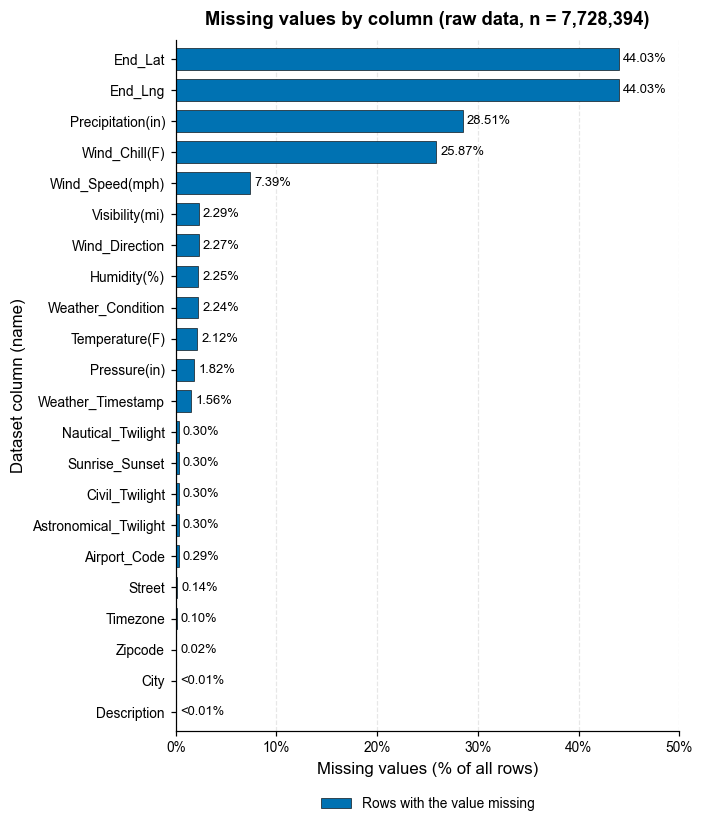

**Figure 1. Missing values by column in the raw data.** Share of the 7,728,394 raw rows with no value in each column; columns without gaps are not shown. 22 of 46 columns have gaps. The largest are the end coordinates (44.0%, recorded after the accident and never used as model inputs), precipitation (28.5%) and wind chill (25.9%); all other weather fields are below 7%. Missing values were kept visible in the cleaned table and imputed only at modelling time, from training rows, because their pattern follows the data-collection period (Figure 3). *Data: US Accidents (Kaggle, March 2023 release), full file.*

⏱ cell run time: 0 min 0.2 s | memory in use: 3.0 GB


In [17]:
from IPython.display import Markdown
uc.figure_style()
CAPTIONS = {}


def publish(fig, number, filename, title, text):
    path = FIG_DIR / filename
    uc.save_figure(fig, path)
    plt.show()
    plt.close(fig)
    caption = f"**Figure {number}. {title}** {text} *Data: US Accidents (Kaggle, March 2023 release), full file.*"
    CAPTIONS[number] = (filename, caption)
    display(Markdown(caption))
    (FIG_DIR / "figure_captions.md").write_text(
        "\n\n".join(f"![Figure {n}]({f})\n\n{c}" for n, (f, c) in sorted(CAPTIONS.items())))


tc = audit["time_checks"]
inv = pd.read_csv(OUT_DIR / "invalid_values_log.csv")
issues = pd.DataFrame([
    ("Missing end coordinates (End_Lat, End_Lng)", int(audit["missing"]["End_Lat"]), "Kept for EDA, not a model input"),
    ("Missing precipitation", int(audit["missing"]["Precipitation(in)"]), "Imputed at modelling time (train only)"),
    ("Street names with stray spaces", int(audit["whitespace"].get("Street", 0)), "Standardised / parsed"),
    ("Weather labels renamed in April 2019", int(clean_log.get("Weather_Condition relabelled (Apr-2019 vocabulary)", 0)), "Standardised / parsed"),
    ("Timestamps with fractional seconds", int(audit["fractional_timestamps"]["Start_Time"]), "Standardised / parsed"),
    ("Rows repeating start/end time and location", int(df["Same_Event_Repeat"].sum()), "Kept + flagged"),
    ("Exact duplicate rows (ID excluded)", int(audit["exact_duplicate_rows"]), "Removed"),
    ("Weather reading > 1 h from accident", int(df["Weather_Stale"].sum()), "Kept + flagged"),
    ("Missing day/night label", int(clean_log.get("Sunrise_Sunset filled from solar position", 0)), "Filled from evidence"),
    ("Missing time zone", int(clean_log.get("Timezone filled from county (or single-timezone state)", 0)), "Filled from evidence"),
    ("Accident duration > 1 year", int(clean_log.get("Duration negative / > 1 year / unparsed -> NaN", 0)), "Set to missing + flagged"),
    ("Weather reading beyond U.S. records", int((inv["tier"] == "plausibility").sum()), "Set to missing + flagged"),
    ("'Unknown' used as a description", int(clean_log.get("Description placeholder ('Unknown' etc.) -> missing", 0)), "Set to missing + flagged"),
    ("Impossible reading (e.g. pressure = 0)", int((inv["tier"] == "definition").sum()), "Set to missing + flagged"),
], columns=["issue", "count", "action"])
issues = issues[issues["count"] > 0]
display(issues.set_index("issue"))          # every issue and its treatment, as a table
raw_missing_pct = audit["missing"] / audit["rows"] * 100
top2 = raw_missing_pct.sort_values(ascending=False)
publish(uc.fig_missing_bars(raw_missing_pct, audit["rows"]), 1, "cleaning_fig1_missing_values.png",
    "Missing values by column in the raw data.",
    f"Share of the {audit['rows']:,} raw rows with no value in each column; columns without gaps are not shown. "
    f"{int((raw_missing_pct > 0).sum())} of {len(raw_missing_pct)} columns have gaps. The largest are the end "
    f"coordinates ({top2['End_Lat']:.1f}%, recorded after the accident and never used as model inputs), precipitation "
    f"({top2['Precipitation(in)']:.1f}%) and wind chill ({top2['Wind_Chill(F)']:.1f}%); all other weather fields are below "
    f"{top2.drop(['End_Lat', 'End_Lng', 'Precipitation(in)', 'Wind_Chill(F)']).max():.0f}%. Missing values were kept "
    f"visible in the cleaned table and imputed only at modelling time, from training rows, because their pattern "
    f"follows the data-collection period (Figure 3).")

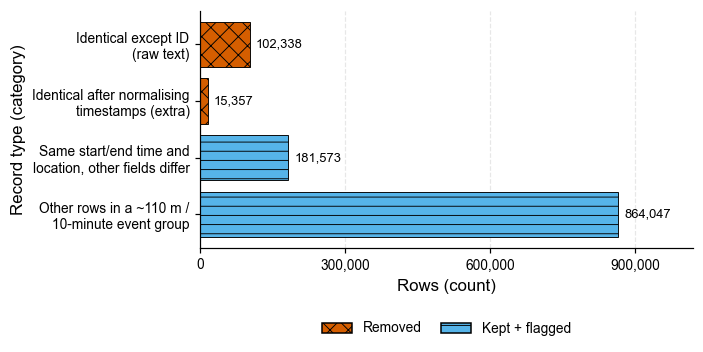

**Figure 2. Four kinds of repeated records, from strictest to loosest definition.** Proven copies (top two bars, 117,695 rows) were removed, keeping the first copy; the second bar only appears when the same instant written as '05:46:00' and '05:46:00.000000000' is treated as equal. The lower bars count every row of a group, including its first report; these probable repeats were kept, flagged, and assigned to one side of every train/test split so that no accident is in both training and test data. *Data: US Accidents (Kaggle, March 2023 release), full file.*

⏱ cell run time: 0 min 0.1 s | memory in use: 3.0 GB


In [18]:
tiers = pd.Series({
    "Identical except ID\n(raw text)": audit["duplicates_raw_text"],
    "Identical after normalising\ntimestamps (extra)": audit["duplicates_from_normalisation"],
    "Same start/end time and\nlocation, other fields differ": int(df["Same_Event_Repeat"].sum()),
    "Other rows in a ~110 m /\n10-minute event group": int(((df["Dup_Group_Size"] > 1) & (df["Same_Event_Repeat"] == 0)).sum()),
})
publish(uc.fig_duplicate_tiers(tiers, ["Removed", "Removed", "Kept + flagged", "Kept + flagged"]), 2,
    "cleaning_fig2_repeated_records.png", "Four kinds of repeated records, from strictest to loosest definition.",
    f"Proven copies (top two bars, {audit['exact_duplicate_rows']:,} rows) were removed, keeping the first copy; the "
    f"second bar only appears when the same instant written as '05:46:00' and '05:46:00.000000000' is treated as equal. "
    f"The lower bars count every row of a group, including its first report; these probable repeats were kept, flagged, "
    f"and assigned to one side of every train/test split so that no accident is in both training and test data.")

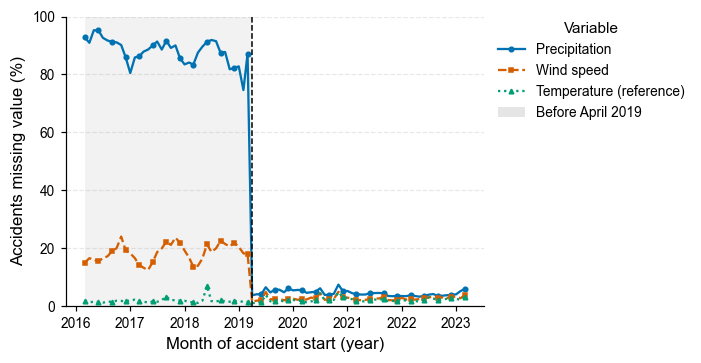

**Figure 3. Weather values are missing by collection period, not at random.** Monthly share of accidents with no precipitation, wind-speed or temperature value (months with at least 1,000 accidents); the shaded area is the period before the April 2019 change in weather data. Precipitation is missing for 87.1% of accidents in the month before the change and 3.7% in the month after, for every provider. A 'value was missing' indicator would therefore encode when an accident was recorded, so missing-value flags are not used as model inputs by default. *Data: US Accidents (Kaggle, March 2023 release), full file.*

⏱ cell run time: 0 min 0.4 s | memory in use: 3.3 GB


In [19]:
month = df["Start_Time"].dt.to_period("M")
monthly = (df[["Precipitation(in)", "Wind_Speed(mph)", "Temperature(F)"]].isna()
           .groupby(month).mean().mul(100))
min_rows = min(1000, int(month.value_counts().median() // 2))
monthly = monthly[month.value_counts().reindex(monthly.index) >= min_rows]
monthly.index = monthly.index.to_timestamp()
monthly.columns = ["Precipitation", "Wind speed", "Temperature (reference)"]
chg = pd.Timestamp(uc.WEATHER_FEED_CHANGE)
before = monthly.loc[monthly.index < chg, "Precipitation"].iloc[-1]
after = monthly.loc[monthly.index >= chg, "Precipitation"].iloc[0]
publish(uc.fig_missing_by_month(monthly, chg), 3, "cleaning_fig3_missing_by_month.png",
    "Weather values are missing by collection period, not at random.",
    f"Monthly share of accidents with no precipitation, wind-speed or temperature value (months with at least "
    f"{min_rows:,} accidents); the shaded area is the period before the April 2019 change in weather data. "
    f"Precipitation is missing for {before:.1f}% of accidents in the month before the change and {after:.1f}% in the "
    f"month after, for every provider. A 'value was missing' indicator would therefore encode when an accident was "
    f"recorded, so missing-value flags are not used as model inputs by default.")

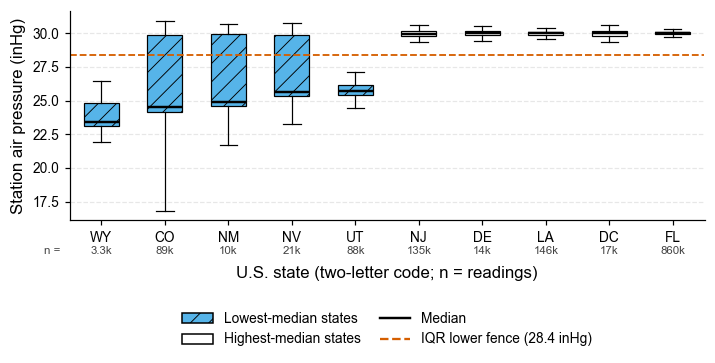

**Figure 4. Low air-pressure readings come from high-elevation states, not from errors.** Station air pressure in the 5 states with the lowest and the 5 with the highest median (boxes: interquartile range; whiskers: 1.5 × IQR; line: median; outliers not drawn; n under each state). A dataset-wide IQR rule would flag 5.8% of all readings below the dashed fence, yet the low-median states (WY 23.4, CO 24.5, NM 24.9 inHg) are high-elevation states where low station pressure is physically normal. Statistical outliers were therefore reported, not removed. *Data: US Accidents (Kaggle, March 2023 release), full file.*

⏱ cell run time: 0 min 0.2 s | memory in use: 3.3 GB


In [20]:
order = pressure_state.dropna()
k = min(5, len(order) // 2)
low_states = list(order.index[:k])
chosen = low_states + [s for s in order.index[-k:] if s not in low_states]
values = {s: df.loc[df["State"] == s, "Pressure(in)"].dropna().to_numpy() for s in chosen}
fence = outliers.loc["Pressure(in)", "lower fence"]
publish(uc.fig_pressure_by_state(values, fence, n_low=len(low_states)), 4, "cleaning_fig4_pressure_by_state.png",
    "Low air-pressure readings come from high-elevation states, not from errors.",
    f"Station air pressure in the {len(low_states)} states with the lowest and the {len(chosen) - len(low_states)} with the highest median (boxes: "
    f"interquartile range; whiskers: 1.5 × IQR; line: median; outliers not drawn; n under each state). A dataset-wide "
    f"IQR rule would flag {outliers.loc['Pressure(in)', '% past fences']:.1f}% of all readings below the dashed fence, yet "
    f"the low-median states ({', '.join(f'{s} {order[s]:.1f}' for s in low_states[:3])} inHg) are high-elevation states "
    f"where low station pressure is physically normal. Statistical outliers were therefore reported, not removed.")

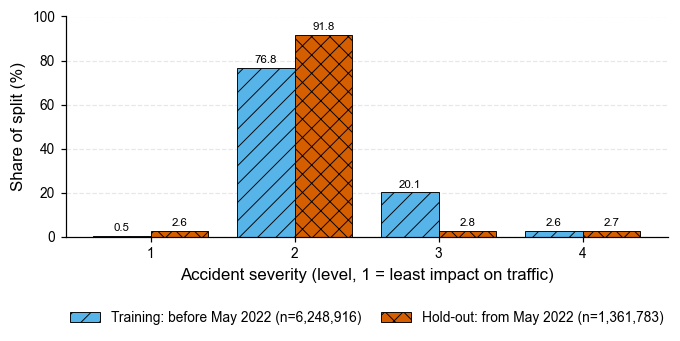

**Figure 5. Severity labels change over time.** Share of accidents at each severity level in the chronological training period and the hold-out period (the most recent 18% of accidents). Severity 3 falls from 20.1% to 2.8% and Severity 1 rises from 0.5% to 2.6%. A random split would hide this drift, so the chronological split is the primary test of future performance. *Data: US Accidents (Kaggle, March 2023 release), full file.*

⏱ cell run time: 0 min 0.3 s | memory in use: 3.3 GB


In [21]:
split_counts = pd.crosstab(df["Severity"], df["Split_Time"]).reindex(columns=["train", "test"])
start = final_info["time split: hold-out starts"]
split_counts.columns = [f"Training: before {pd.Timestamp(start):%b %Y}", f"Hold-out: from {pd.Timestamp(start):%b %Y}"]
sh = split_counts / split_counts.sum() * 100
publish(uc.fig_severity_by_split(split_counts), 5, "cleaning_fig5_severity_by_split.png",
    "Severity labels change over time.",
    f"Share of accidents at each severity level in the chronological training period and the hold-out period "
    f"(the most recent {split_counts.iloc[:, 1].sum() / split_counts.values.sum() * 100:.0f}% of accidents). Severity 3 "
    f"falls from {sh.iloc[2, 0]:.1f}% to {sh.iloc[2, 1]:.1f}% and Severity 1 rises from {sh.iloc[0, 0]:.1f}% to "
    f"{sh.iloc[0, 1]:.1f}%. A random split would hide this drift, so the chronological split is the primary test of "
    f"future performance.")

## 8. Key numbers for the report

Every number quoted in the written report, collected in one table and saved to `data/clean/report_numbers.csv`.

In [22]:
month = df["Start_Time"].dt.to_period("M")
precip_month = df["Precipitation(in)"].isna().groupby(month).mean().mul(100)
change = pd.Period(uc.WEATHER_FEED_CHANGE, "M")
inv = pd.read_csv(OUT_DIR / "invalid_values_log.csv")
numbers = {
    "raw rows": audit["rows"], "raw columns": len(audit["columns"]),
    "duplicates, raw text (ID excluded)": audit["duplicates_raw_text"],
    "duplicates, extra after normalisation": audit["duplicates_from_normalisation"],
    "duplicates removed (total)": audit["exact_duplicate_rows"],
    "rows after cleaning": len(df), "columns after cleaning": len(uc.clean_columns(FINAL_PATH)),
    "rows sharing start/end time and location (kept, flagged)": int(df["Same_Event_Repeat"].sum()),
    "rows in event groups (kept, flagged)": int((df["Dup_Group_Size"] > 1).sum()),
    "rows in cross-provider groups": int((df["Dup_Source_Count"] > 1).sum()),
    "rows in groups with conflicting Severity": int(df["Dup_Severity_Conflict"].sum()),
    "fractional-second Start_Time values": audit["fractional_timestamps"]["Start_Time"],
    "durations > 365 days (set to missing)": int(audit["time_checks"]["Duration > 365 days"]),
    "weather reading > 1 h from start": int(audit["time_checks"]["Weather_Timestamp > 1 h from start"]),
    "Street values with leading/trailing spaces": int(audit["whitespace"].get("Street", 0)),
    "Description 'Unknown' placeholders": int(clean_log.get("Description placeholder ('Unknown' etc.) -> missing", 0)),
    "'N/A Precipitation' labels": audit["na_precipitation_rows"],
    "weather labels harmonised (Apr 2019 vocabulary)": int(clean_log.get("Weather_Condition relabelled (Apr-2019 vocabulary)", 0)),
    "precipitation missing, month before Apr 2019 (%)": round(float(precip_month.loc[change - 1]), 1),
    "precipitation missing, Apr 2019 (%)": round(float(precip_month.loc[change]), 1),
    "masked values in total (invalid_values_log.csv)": len(inv),
    "masked: definition-invalid": int((inv["tier"] == "definition").sum()),
    "masked: implausible (beyond US records)": int((inv["tier"] == "plausibility").sum()),
    **{f"masked: {c}": int(n) for c, n in inv["column"].value_counts().items()},
    "Sunrise_Sunset filled from solar position": int(clean_log.get("Sunrise_Sunset filled from solar position", 0)),
    "Sunrise_Sunset agreement with solar position (%)": clean_log.get("Sunrise_Sunset agreement with solar position (%)", None),
    "Timezone filled from county / single-timezone state": int(clean_log.get("Timezone filled from county (or single-timezone state)", 0)),
    "Timezone left missing": int(clean_log.get("Timezone left missing (county and state span several zones)", 0)),
    **{k: v for k, v in final_info.items() if "split" in k},
    **{f"Severity {k} after cleaning": int(v) for k, v in df["Severity"].value_counts().sort_index().items()},
}
report_numbers = pd.Series(numbers, name="value").astype(str)
report_numbers.to_csv(OUT_DIR / "report_numbers.csv")
with pd.option_context("display.max_rows", 100):
    display(report_numbers.to_frame())

,value
raw rows,7728394
raw columns,46
"duplicates, raw text (ID excluded)",102338
"duplicates, extra after normalisation",15357
duplicates removed (total),117695
rows after cleaning,7610699
columns after cleaning,79
"rows sharing start/end time and location (kept, flagged)",181573
"rows in event groups (kept, flagged)",1045620
rows in cross-provider groups,8566


⏱ cell run time: 0 min 0.3 s | memory in use: 3.3 GB


## 9. Hand-off: data dictionary and how to use the file

In [23]:
dictionary = uc.dictionary_from_scan(SCAN)
dictionary.to_csv(OUT_DIR / "data_dictionary.csv", index=False)
log = {"audit": {k: (v if isinstance(v, (int, float, str, list, dict)) else str(v))
                 for k, v in audit.items() if k not in ("dup_hashes", "row_hashes", "missing", "invalid",
                                                        "numeric_range", "severity_counts", "labels")},
       "raw_invalid": audit["invalid"].to_dict(), "cleaning": clean_log, "final": final_info}
(OUT_DIR / "cleaning_log.json").write_text(json.dumps(log, indent=2, default=str))
with pd.option_context("display.max_rows", 100):
    display(dictionary)

,column,dtype,role,missing %,distinct
0,ID,string,identifier,0.000,7610699
1,Source,string,label_process,0.000,3
2,Severity,int8,target,0.000,4
3,Start_Time,datetime64[ns],eda_only,0.000,5801064
4,End_Time,datetime64[ns],leakage_post_event,0.000,6463005
5,Duration_min,float32,leakage_post_event,0.048,73766
6,Duration_invalid,Int8,quality_flag,0.000,2
7,Start_Year,int16,label_process,0.000,8
8,Start_Month,Int8,label_process,0.000,12
9,Start_DayOfWeek,Int8,feature,0.000,7


⏱ cell run time: 0 min 0.0 s | memory in use: 3.3 GB


```python
import us_accidents_cleaning as uc
df = uc.load_clean("data/clean/us_accidents_clean")                      # EDA (no Description/Street)
counts = uc.events_only(df)                                               # dashboard COUNTS: 1 row per accident
df = uc.load_clean("data/clean/us_accidents_clean",
                   columns=["Severity", "State", "Start_Hour", "Weather_Group"])  # lighter
X_cp, _ = uc.build_model_frame(df[df.Split_Time == "train"], stats,
                               include_label_process=True, missing_flags=True)  # only if the team decides
stats = uc.load_imputation_stats("data/clean/imputation_stats.csv")
X_tr, y_tr = uc.build_model_frame(df[df.Split_Time == "train"], stats)     # ML, chronological (primary)
X_te, y_te = uc.build_model_frame(df[df.Split_Time == "test"], stats)
# Random event-grouped split: use the matching medians
rstats = uc.load_imputation_stats("data/clean/imputation_stats_random.csv")
X_rtr, y_rtr = uc.build_model_frame(df[df.Split == "train"], rstats)
```
Rules for everyone: do not refit imputation on all rows; do not use `leakage_post_event` columns as features; `Source` and `Start_Year` are `label_process` columns — include them only if the team decides to (`include_label_process=True`).

In [24]:
# Final self-checks (fail loudly if a later edit breaks the pipeline)
# (checked on every row of the full table, one block at a time - see uc.scan_clean)
assert SCAN["id_unique"], "duplicate IDs"
assert all(v == 0 for v in SCAN["checks"].values()), {k: v for k, v in SCAN["checks"].items() if v}
assert not set(uc.DROPPED_COLUMNS) & set(SCAN["columns"])
print("All checks passed.")

All checks passed.
⏱ cell run time: 0 min 0.0 s | memory in use: 3.3 GB


## Done — where your results are
Everything is in the CSV's folder. The cell below lists the files. For GitHub, commit the notebook (with outputs), `src/us_accidents_cleaning.py`, `figures/` and the small CSV/JSON files in `data/clean/` — **not** the raw CSV or the parquet folder (too large; link the Kaggle page instead).

In [25]:
for p in sorted(Path("figures").glob("*.png")) + sorted(Path("data/clean").glob("*.*")):
    print(f"{p}  ({p.stat().st_size / 1e6:.1f} MB)")
parts = list((OUT_DIR / "us_accidents_clean").glob("part_*"))
size_gb = sum(f.stat().st_size for f in parts) / 1e9
print(f"Cleaned dataset: {len(df):,} rows x {len(uc.clean_columns(FINAL_PATH))} columns, "
      f"{size_gb:.2f} GB on disk in {len(parts)} {'compressed parquet' if parts and parts[0].suffix == '.parquet' else 'uncompressed pickle'} "
      f"files (raw CSV: {CSV_PATH.stat().st_size / 1e9:.2f} GB)")
if parts and parts[0].suffix != ".parquet":
    print("Tip: install pyarrow (pip install pyarrow) and run again - the cleaned data is then saved as "
          "compressed parquet, about 0.8 GB instead of ~2.8 GB, and loads faster.")

figures/cleaning_fig1_missing_values.png  (0.5 MB)
figures/cleaning_fig2_repeated_records.png  (0.2 MB)
figures/cleaning_fig3_missing_by_month.png  (0.2 MB)
figures/cleaning_fig4_pressure_by_state.png  (0.2 MB)
figures/cleaning_fig5_severity_by_split.png  (0.2 MB)
data/clean/cleaning_log.json  (0.1 MB)
data/clean/data_dictionary.csv  (0.0 MB)
data/clean/imputation_stats.csv  (0.2 MB)
data/clean/imputation_stats_random.csv  (0.2 MB)
data/clean/invalid_values_log.csv  (0.0 MB)
data/clean/report_numbers.csv  (0.0 MB)
Cleaned dataset: 7,610,699 rows x 79 columns, 2.79 GB on disk in 31 uncompressed pickle files (raw CSV: 3.06 GB)
Tip: install pyarrow (pip install pyarrow) and run again - the cleaned data is then saved as compressed parquet, about 0.8 GB instead of ~2.8 GB, and loads faster.
⏱ cell run time: 0 min 0.1 s | memory in use: 3.3 GB
